# Null Space Analysis

This notebook will extract and analyze neuron spiking data from NWB files.


In [47]:
import os
from pathlib import Path
from pynwb import NWBHDF5IO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set up paths
data_root = Path("/Users/jundazhu/SBCAT/000673")


## All Functions

All functions are defined below, organized by category:
- **Trial Selection**: Select trials by load, correctness, probe in/out, or indices
- **File Listing**: List and select NWB files
- **Data Extraction**: Extract spike data and trial information from NWB files
- **DataFrame Creation**: Convert extraction results to DataFrames
- **Spike Segmentation**: Segment spikes by trials, aligned to specific events
- **Workflow**: Process single or multiple sessions

In [48]:
def select_trials_by_load(trials_df, load_values):
    """
    Select trials by memory load values (session-level).
    
    Args:
        trials_df: DataFrame with trial information for a session
        load_values: Single load value (int) or list of load values (e.g., [1, 3])
    
    Returns:
        selected_trials_df: Filtered DataFrame with selected trials
        selected_indices: Array of trial indices (0-based) in original trials_df
    
    Note: Works at session level - select trials once per session, use for all units in that session.
    """
    if 'loads' not in trials_df.columns:
        raise ValueError("trials_df must have a 'loads' column")
    
    if not isinstance(load_values, (list, tuple, np.ndarray)):
        load_values = [load_values]
    
    mask = trials_df['loads'].isin(load_values)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    
    return selected_trials_df, selected_indices


def select_trials_by_correctness(trials_df, correct_only=True):
    """
    Select trials by correctness (session-level).
    
    Args:
        trials_df: DataFrame with trial information for a session
        correct_only: If True, select only correct trials. If False, select only incorrect trials.
    
    Returns:
        selected_trials_df: Filtered DataFrame with selected trials
        selected_indices: Array of trial indices (0-based) in original trials_df
    
    Note: Works at session level - select trials once per session, use for all units in that session.
    """
    if 'response_accuracy' not in trials_df.columns:
        raise ValueError("trials_df must have a 'response_accuracy' column")
    
    if correct_only:
        mask = (trials_df['response_accuracy'] == 1)
    else:
        mask = (trials_df['response_accuracy'] != 1)
    
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    
    return selected_trials_df, selected_indices


def select_trials_by_probe_in_out(trials_df, probe_in_out):
    """
    Select trials by probe in/out status (session-level).
    
    Args:
        trials_df: DataFrame with trial information for a session
        probe_in_out: 'in' or 'out' to select probe in set or probe out set
    
    Returns:
        selected_trials_df: Filtered DataFrame with selected trials
        selected_indices: Array of trial indices (0-based) in original trials_df
    
    Note: Works at session level - select trials once per session, use for all units in that session.
    """
    if 'probe_in_out' not in trials_df.columns:
        raise ValueError("trials_df must have a 'probe_in_out' column")
    
    mask = (trials_df['probe_in_out'] == probe_in_out)
    selected_indices = np.where(mask)[0]
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    
    return selected_trials_df, selected_indices


def select_trials_by_indices(trials_df, trial_indices):
    """
    Select trials by explicit trial indices (session-level).
    
    Args:
        trials_df: DataFrame with trial information for a session
        trial_indices: List/array of trial indices to select (0-based)
    
    Returns:
        selected_trials_df: Filtered DataFrame with selected trials
        selected_indices: Array of trial indices (0-based) in original trials_df
    
    Note: Works at session level - select trials once per session, use for all units in that session.
    """
    selected_indices = np.array(trial_indices)
    selected_trials_df = trials_df.iloc[selected_indices].copy()
    return selected_trials_df, selected_indices


# ============================================================================
# File Listing Functions
# ============================================================================

def list_available_files(data_dir):
    """List all available NWB files with indices for selection."""
    files = sorted(data_dir.rglob("*.nwb"))
    print(f"Found {len(files)} NWB files:\n")
    for i, f in enumerate(files):
        rel_path = f.relative_to(data_dir)
        print(f"{i:3d}. {rel_path}")
    return files


# ============================================================================
# Data Extraction Functions
# ============================================================================

def extract_spike_data(filepath, include_waveforms=False, quality_filters=None, include_trials=True):
    """
    Extract spike data from a single NWB file.
    
    Args:
        filepath: Path to NWB file
        include_waveforms: If True, include spike waveforms (memory intensive)
        quality_filters: Dict with quality filter criteria, e.g.:
            {'min_snr': 1.0, 'min_isolation_distance': 5.0}
        include_trials: If True, extract trial information
    
    Returns:
        dict with keys:
            - 'filepath': Path to source file
            - 'subject_id': Subject ID extracted from filename
            - 'session_id': Session ID extracted from filename
            - 'units': List of dicts, each containing unit data
            - 'trials': DataFrame with trial information (if include_trials=True)
    """
    filepath = Path(filepath)
    
    # Extract subject and session from filename
    parts = filepath.stem.split('_')
    subject_id = None
    session_id = None
    for part in parts:
        if part.startswith('sub-'):
            subject_id = int(part.split('-')[1])
        elif part.startswith('ses-'):
            session_id = int(part.split('-')[1])
    
    result = {
        'filepath': str(filepath),
        'subject_id': subject_id,
        'session_id': session_id,
        'units': []
    }
    
    try:
        with NWBHDF5IO(str(filepath), mode="r", load_namespaces=True) as io:
            nwbf = io.read()
            
            # Extract trials
            if include_trials and nwbf.trials is not None:
                try:
                    trials_df = nwbf.trials.to_dataframe()
                    result['trials'] = trials_df
                except Exception as e:
                    print(f"Warning: Could not extract trials from {filepath.name}: {e}")
                    result['trials'] = None
            else:
                result['trials'] = None
            
            if nwbf.units is None:
                print(f"Warning: No units found in {filepath.name}")
                return result
            
            # Get units table
            units_df = nwbf.units.to_dataframe()
            electrodes_df = nwbf.electrodes.to_dataframe() if nwbf.electrodes is not None else None
            
            # Extract data for each unit
            for unit_idx in units_df.index:
                unit_data = {
                    'unit_id': int(unit_idx),
                    'spike_times': None,
                    'electrode_idx': None,
                    'cluster_id': None,
                    'mean_snr': None,
                    'peak_snr': None,
                    'isolation_distance': None,
                    'mean_proj_dist': None,
                    'n_spikes': 0,
                    'brain_region': None
                }
                
                # Extract spike times
                try:
                    spike_times = np.array(nwbf.units['spike_times'][unit_idx][:])
                    unit_data['spike_times'] = spike_times
                    unit_data['n_spikes'] = len(spike_times)
                except Exception as e:
                    print(f"Warning: Could not extract spike times for unit {unit_idx}: {e}")
                    continue
                
                # Extract electrode information
                if 'electrodes' in units_df.columns:
                    try:
                        electrode_info = units_df.loc[unit_idx, 'electrodes']
                        # Electrode info might be a table or index
                        if hasattr(electrode_info, 'index'):
                            unit_data['electrode_idx'] = int(electrode_info.index[0]) if len(electrode_info.index) > 0 else None
                        else:
                            unit_data['electrode_idx'] = int(electrode_info) if pd.notna(electrode_info) else None
                        
                        # Get brain region from electrode
                        if unit_data['electrode_idx'] is not None and electrodes_df is not None:
                            if 'location' in electrodes_df.columns:
                                unit_data['brain_region'] = electrodes_df.loc[unit_data['electrode_idx'], 'location']
                    except Exception as e:
                        pass  # Electrode info might not be available
                
                # Extract quality metrics
                if 'clusterID_orig' in units_df.columns:
                    unit_data['cluster_id'] = units_df.loc[unit_idx, 'clusterID_orig']
                if 'waveforms_mean_snr' in units_df.columns:
                    unit_data['mean_snr'] = units_df.loc[unit_idx, 'waveforms_mean_snr']
                if 'waveforms_peak_snr' in units_df.columns:
                    unit_data['peak_snr'] = units_df.loc[unit_idx, 'waveforms_peak_snr']
                if 'waveforms_isolation_distance' in units_df.columns:
                    unit_data['isolation_distance'] = units_df.loc[unit_idx, 'waveforms_isolation_distance']
                if 'waveforms_mean_proj_dist' in units_df.columns:
                    unit_data['mean_proj_dist'] = units_df.loc[unit_idx, 'waveforms_mean_proj_dist']
                
                # Apply quality filters
                if quality_filters is not None:
                    skip_unit = False
                    if 'min_snr' in quality_filters and unit_data['mean_snr'] is not None:
                        if unit_data['mean_snr'] < quality_filters['min_snr']:
                            skip_unit = True
                    if 'min_isolation_distance' in quality_filters and unit_data['isolation_distance'] is not None:
                        if unit_data['isolation_distance'] < quality_filters['min_isolation_distance']:
                            skip_unit = True
                    if 'min_n_spikes' in quality_filters:
                        if unit_data['n_spikes'] < quality_filters['min_n_spikes']:
                            skip_unit = True
                    if skip_unit:
                        continue
                
                # Extract waveforms if requested
                if include_waveforms and 'waveforms' in units_df.columns:
                    try:
                        waveforms = np.array(nwbf.units['waveforms'][unit_idx][:])
                        unit_data['waveforms'] = waveforms
                    except Exception as e:
                        pass  # Waveforms might not be available
                
                result['units'].append(unit_data)
    
    except Exception as e:
        print(f"Error processing {filepath.name}: {e}")
        import traceback
        traceback.print_exc()
    
    return result


def batch_extract_spike_data(filepaths, include_waveforms=False, quality_filters=None, include_trials=True, verbose=True):
    """
    Extract spike data from multiple NWB files in batch.
    
    Args:
        filepaths: List of NWB file paths or single path
        include_waveforms: If True, include spike waveforms
        quality_filters: Dict with quality filter criteria
        include_trials: If True, extract trial information
        verbose: If True, print progress
    
    Returns:
        List of extraction results (one per file)
    """
    if isinstance(filepaths, (str, Path)):
        filepaths = [filepaths]
    
    results = []
    n_files = len(filepaths)
    
    for i, filepath in enumerate(filepaths, 1):
        if verbose:
            print(f"Processing file {i}/{n_files}: {Path(filepath).name}")
        
        result = extract_spike_data(
            filepath, 
            include_waveforms=include_waveforms,
            quality_filters=quality_filters,
            include_trials=include_trials
        )
        results.append(result)
        
        if verbose:
            n_units = len(result['units'])
            n_trials = len(result['trials']) if result['trials'] is not None else 0
            print(f"  Extracted {n_units} units, {n_trials} trials")
    
    return results


# ============================================================================
# DataFrame Creation Functions
# ============================================================================

def create_spike_dataframe(extraction_results):
    """
    Convert extraction results to a pandas DataFrame for easy analysis.
    
    Args:
        extraction_results: List of extraction result dicts
    
    Returns:
        DataFrame with one row per unit
    """
    rows = []
    
    for result in extraction_results:
        for unit in result['units']:
            row = {
                'subject_id': result['subject_id'],
                'session_id': result['session_id'],
                'filepath': result['filepath'],
                'unit_id': unit['unit_id'],
                'n_spikes': unit['n_spikes'],
                'electrode_idx': unit['electrode_idx'],
                'brain_region': unit['brain_region'],
                'cluster_id': unit['cluster_id'],
                'mean_snr': unit['mean_snr'],
                'peak_snr': unit['peak_snr'],
                'isolation_distance': unit['isolation_distance'],
                'mean_proj_dist': unit['mean_proj_dist'],
                'spike_times': unit['spike_times']  # Keep as array
            }
            rows.append(row)
    
    return pd.DataFrame(rows)


def extract_trials_dataframe(extraction_results):
    """
    Extract trial information from extraction results.
    
    Args:
        extraction_results: List of extraction result dicts
    
    Returns:
        DataFrame with trial information, including subject/session identifiers
    """
    trial_rows = []
    
    for result in extraction_results:
        if result['trials'] is not None:
            trials_df = result['trials'].copy()
            trials_df['subject_id'] = result['subject_id']
            trials_df['session_id'] = result['session_id']
            trials_df['filepath'] = result['filepath']
            trial_rows.append(trials_df)
    
    if len(trial_rows) == 0:
        return pd.DataFrame()
    
    return pd.concat(trial_rows, ignore_index=True)


# ============================================================================
# Spike Segmentation Functions
# ============================================================================

def segment_spikes_by_trials(spike_times, trials_df, align_to='start_time', time_window=None):
    """
    Segment spikes by trials, aligned to a specific event timestamp.

    Args:
        spike_times: Array of spike timestamps (seconds)
        trials_df: DataFrame with trial information
        align_to: Column name in trials_df to align to:
                  - 'start_time': Trial start (default)
                  - 'timestamps_Probe': Probe onset
                  - 'timestamps_Encoding1': First encoding start
                  - 'timestamps_Maintenance': Maintenance start
                  - 'timestamps_Response': Response time
        time_window: Tuple (start_offset, end_offset) relative to alignment point in seconds.
                     If None, uses full trial (start_time to stop_time)

    Returns:
        List of arrays, one per trial, containing aligned spike times
    """
    segmented_spikes = []

    for trial_idx, trial in trials_df.iterrows():
        # Get alignment point
        if align_to in trial and pd.notna(trial[align_to]) and trial[align_to] > 0:
            alignment_point = trial[align_to]
        elif 'start_time' in trial:
            alignment_point = trial['start_time']
        else:
            segmented_spikes.append(np.array([]))
            continue

        # Determine time window
        if time_window is not None:
            window_start = alignment_point + time_window[0]
            window_end = alignment_point + time_window[1]
        else:
            # Use full trial
            window_start = trial.get('start_time', alignment_point)
            window_end = trial.get('stop_time', alignment_point + 10.0)  # Default 10s if no stop_time

        # Extract spikes in this window
        mask = (spike_times >= window_start) & (spike_times < window_end)
        trial_spikes = spike_times[mask]

        # Align spikes to alignment point
        aligned_spikes = trial_spikes - alignment_point

        segmented_spikes.append(aligned_spikes)

    return segmented_spikes


def segment_spikes_by_selected_trials(spike_times, trials_df, selected_trial_indices=None,
                                      align_to='start_time', time_window=None):
    """
    Segment spikes by selected trials, aligned to a specific event.

    Args:
        spike_times: Array of spike timestamps
        trials_df: DataFrame with trial information
        selected_trial_indices: Array/list of trial indices to use (0-based).
                               If None, uses all trials.
        align_to: Column name in trials_df to align to (e.g., 'timestamps_Probe', 'start_time')
        time_window: Tuple (start_offset, end_offset) relative to alignment point

    Returns:
        List of arrays, one per selected trial, containing aligned spike times
    """
    if selected_trial_indices is not None:
        selected_trials_df = trials_df.iloc[selected_trial_indices].copy()
        selected_trials_df = selected_trials_df.reset_index(drop=True)
    else:
        selected_trials_df = trials_df

    return segment_spikes_by_trials(
        spike_times,
        selected_trials_df,
        align_to=align_to,
        time_window=time_window
    )


# ============================================================================
# Workflow Functions
# ============================================================================

def process_session(filepath, selected_trial_indices=None, align_to='start_time', time_window=None, 
                     trial_groups=None, group_labels=None):
    """
    Process a single session: extract units, select trials, segment spikes.
    
    Args:
        filepath: Path to NWB file
        selected_trial_indices: Array/list of trial indices to use (0-based) for this session.
                               If None, uses all trials.
        align_to: Column name in trials_df to align to (e.g., 'timestamps_Probe', 'start_time')
        time_window: Tuple (start_offset, end_offset) relative to alignment point in seconds.
                     If None, uses full trial.
        trial_groups: List of arrays, where each array contains trial indices for that group.
                     Example: [np.array([0, 1, 2]), np.array([3, 4, 5])] → 2 groups.
                     Trial indices are relative to selected_trial_indices (0-based within selected trials).
                     If None, no group info stored (backward compatible).
        group_labels: List of group names (e.g., ['L1', 'L3']). If None, uses default ['group0', 'group1', ...].
    
    Returns:
        session_df: DataFrame with one row per unit, including:
            - All unit metadata (subject_id, session_id, unit_id, etc.)
            - 'spike_times': Original spike times array
            - 'segmented_spikes': List of arrays, one per selected trial, with aligned spike times
            - 'n_trials': Number of trials used
            - 'selected_trial_indices': Trial indices used for this session
            - 'trial_groups': List of arrays with trial group indices (if provided)
            - 'group_labels': List of group names (if provided)
    """
    # Extract data from file
    result = extract_spike_data(filepath, include_trials=True)
    
    if result['trials'] is None or len(result['trials']) == 0:
        print(f"Warning: No trials found in {Path(filepath).name}")
        return None
    
    if len(result['units']) == 0:
        print(f"Warning: No units found in {Path(filepath).name}")
        return None
    
    # Get trials for this session
    trials_df = result['trials'].copy()
    trials_df = trials_df.reset_index(drop=True)
    
    # Use all trials if none selected
    if selected_trial_indices is None:
        selected_trial_indices = np.arange(len(trials_df))
    
    # Set default group labels if trial_groups provided but group_labels not
    if trial_groups is not None and group_labels is None:
        group_labels = [f'group{i}' for i in range(len(trial_groups))]
    
    # Build DataFrame of all units in this session
    unit_rows = []
    
    for unit in result['units']:
        spike_times = unit['spike_times']
        
        # Segment spikes using selected trials (keep all trials)
        segmented = segment_spikes_by_selected_trials(
            spike_times,
            trials_df,
            selected_trial_indices=selected_trial_indices,
            align_to=align_to,
            time_window=time_window
        )
        
        # Create row for this unit
        row = {
            'subject_id': result['subject_id'],
            'session_id': result['session_id'],
            'filepath': result['filepath'],
            'unit_id': unit['unit_id'],
            'n_spikes': unit['n_spikes'],
            'electrode_idx': unit['electrode_idx'],
            'brain_region': unit['brain_region'],
            'cluster_id': unit['cluster_id'],
            'mean_snr': unit['mean_snr'],
            'peak_snr': unit['peak_snr'],
            'isolation_distance': unit['isolation_distance'],
            'mean_proj_dist': unit['mean_proj_dist'],
            'spike_times': spike_times,  # Original spike times
            'segmented_spikes': segmented,  # Segmented by trials (all trials kept)
            'n_trials': len(segmented),
            'selected_trial_indices': selected_trial_indices  # Store which trials were used
        }
        
        # Store group info if provided
        if trial_groups is not None:
            row['trial_groups'] = trial_groups
            row['group_labels'] = group_labels
        
        unit_rows.append(row)
    
    session_df = pd.DataFrame(unit_rows)
    return session_df


def process_multiple_sessions(filepaths, trial_selection_func=None, align_to='start_time', time_window=None, 
                              trial_groups_dict=None, group_labels=None, verbose=True):
    """
    Process multiple sessions and compile results.
    
    Args:
        filepaths: List of NWB file paths
        trial_selection_func: Function that takes (trials_df, filepath) and returns selected_trial_indices.
                             If None, uses all trials for each session.
                             Example: lambda trials_df, fp: select_trials_by_load(trials_df, [1])[1]
        align_to: Column name to align to
        time_window: Tuple (start_offset, end_offset) relative to alignment point
        trial_groups_dict: Dictionary mapping filepath or session_id to trial_groups list.
                         Example: {filepath1: [np.array([0,1,2]), np.array([3,4])], ...}
                         Trial indices are relative to selected_trial_indices (0-based within selected trials).
                         If None, no group info stored (backward compatible).
        group_labels: List of group names to use across all sessions (e.g., ['L1', 'L3']).
                     If None, uses default ['group0', 'group1', ...] when trial_groups_dict is provided.
        verbose: If True, print progress
    
    Returns:
        compiled_df: DataFrame with all units from all sessions (all trials + group info stored)
    """
    all_session_dfs = []
    
    for i, filepath in enumerate(filepaths, 1):
        if verbose:
            print(f"Processing session {i}/{len(filepaths)}: {Path(filepath).name}")
        
        # Extract trials first to determine selection
        result = extract_spike_data(filepath, include_trials=True, include_waveforms=False)
        
        if result['trials'] is None or len(result['trials']) == 0:
            if verbose:
                print(f"  Skipping: No trials found")
            continue
        
        trials_df = result['trials'].copy()
        trials_df = trials_df.reset_index(drop=True)
        
        # Select trials for this session
        if trial_selection_func is not None:
            selected_trial_indices = trial_selection_func(trials_df, filepath)
        else:
            selected_trial_indices = None  # Use all trials
        
        if verbose and selected_trial_indices is not None:
            print(f"  Selected {len(selected_trial_indices)} trials")
        
        # Look up trial_groups for this session
        trial_groups = None
        if trial_groups_dict is not None:
            # Try to find by filepath (as string or Path)
            filepath_str = str(filepath)
            filepath_path = Path(filepath)
            
            # Try exact match first
            if filepath_str in trial_groups_dict:
                trial_groups = trial_groups_dict[filepath_str]
            elif filepath_path in trial_groups_dict:
                trial_groups = trial_groups_dict[filepath_path]
            else:
                # Try matching by filename or relative path
                for key in trial_groups_dict:
                    if str(key) == filepath_str or str(key) == str(filepath_path):
                        trial_groups = trial_groups_dict[key]
                        break
                    # Also try matching by filename only
                    if Path(key).name == filepath_path.name:
                        trial_groups = trial_groups_dict[key]
                        break
        
        # Process session (pass trial_groups and group_labels)
        session_df = process_session(
            filepath,
            selected_trial_indices=selected_trial_indices,
            align_to=align_to,
            time_window=time_window,
            trial_groups=trial_groups,
            group_labels=group_labels
        )
        
        if session_df is not None:
            all_session_dfs.append(session_df)
            if verbose:
                print(f"  Extracted {len(session_df)} units")
                if trial_groups is not None:
                    print(f"  Stored {len(trial_groups)} trial groups")
    
    # Compile all sessions
    if len(all_session_dfs) == 0:
        print("Warning: No sessions processed successfully")
        return pd.DataFrame()
    
    compiled_df = pd.concat(all_session_dfs, ignore_index=True)
    
    if verbose:
        print(f"\n✓ Compiled {len(compiled_df)} units from {len(all_session_dfs)} sessions")
        if trial_groups_dict is not None:
            print(f"  Group info stored in compiled_df columns")
    
    return compiled_df


# ============================================================================
# Brain Region Selection Functions
# ============================================================================

def collapse_hemispheres(compiled_df, inplace=False):
    """
    Collapse left/right hemispheres of the same brain area.
    
    Removes "_left" and "_right" suffixes from brain region names (case-insensitive).
    Creates a new column 'brain_region_collapsed' with collapsed region names.
    
    Args:
        compiled_df: DataFrame with 'brain_region' column
        inplace: If True, modify DataFrame in place; if False, return new DataFrame
    
    Returns:
        DataFrame with 'brain_region_collapsed' column added
    
    Examples:
        "CA1_left" → "CA1"
        "CA1_right" → "CA1"
        "CA1" → "CA1"
        "PFC_Left" → "PFC"
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    
    df = compiled_df if inplace else compiled_df.copy()
    
    def collapse_region(region):
        """Remove _left or _right suffix from region name."""
        if pd.isna(region) or region is None:
            return region
        
        region_str = str(region).strip()
        
        # Remove _left or _right suffix (case-insensitive)
        if region_str.lower().endswith('_left'):
            return region_str[:-5]  # Remove "_left"
        elif region_str.lower().endswith('_right'):
            return region_str[:-6]  # Remove "_right"
        else:
            return region_str  # Already collapsed or no suffix
    
    df['brain_region_collapsed'] = df['brain_region'].apply(collapse_region)
    
    return df


def list_available_brain_regions(compiled_df, show_collapsed=True):
    """
    List available brain regions in a DataFrame.
    
    Args:
        compiled_df: DataFrame with 'brain_region' column
        show_collapsed: If True, also show collapsed regions
    
    Returns:
        original_regions: List of unique original brain regions
        collapsed_regions: List of unique collapsed brain regions (if show_collapsed=True)
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    
    # Get original regions
    original_regions = compiled_df['brain_region'].dropna().unique()
    original_regions = sorted([str(r) for r in original_regions if r is not None])
    
    print("=== Available Brain Regions ===")
    print(f"\nOriginal regions ({len(original_regions)}):")
    for i, region in enumerate(original_regions, 1):
        count = len(compiled_df[compiled_df['brain_region'] == region])
        print(f"  {i:2d}. {region:30s} ({count} units)")
    
    if show_collapsed:
        # Collapse if not already done
        if 'brain_region_collapsed' not in compiled_df.columns:
            df_temp = collapse_hemispheres(compiled_df.copy())
        else:
            df_temp = compiled_df
        
        collapsed_regions = df_temp['brain_region_collapsed'].dropna().unique()
        collapsed_regions = sorted([str(r) for r in collapsed_regions if r is not None])
        
        print(f"\nCollapsed regions ({len(collapsed_regions)}):")
        for i, region in enumerate(collapsed_regions, 1):
            count = len(df_temp[df_temp['brain_region_collapsed'] == region])
            print(f"  {i:2d}. {region:30s} ({count} units)")
        
        return original_regions, collapsed_regions
    
    return original_regions, None


def select_units_by_brain_region(compiled_df, brain_regions, match_type='exact', use_collapsed=True):
    """
    Select units based on brain region.
    
    Args:
        compiled_df: DataFrame with 'brain_region' column
        brain_regions: String or list of strings (brain region names to select)
        match_type: 'exact' or 'contains' (for partial matching)
        use_collapsed: If True, use 'brain_region_collapsed' column; if False, use 'brain_region'
    
    Returns:
        filtered_df: Filtered DataFrame with selected units
    
    Examples:
        # Select CA1 units (both left and right if collapsed)
        select_units_by_brain_region(df, 'CA1', use_collapsed=True)
        
        # Select multiple regions
        select_units_by_brain_region(df, ['CA1', 'CA3'], use_collapsed=True)
        
        # Partial match
        select_units_by_brain_region(df, 'CA', match_type='contains', use_collapsed=True)
    """
    if 'brain_region' not in compiled_df.columns:
        raise ValueError("DataFrame must have a 'brain_region' column")
    
    # Ensure collapsed column exists if needed
    if use_collapsed:
        if 'brain_region_collapsed' not in compiled_df.columns:
            compiled_df = collapse_hemispheres(compiled_df.copy())
        region_col = 'brain_region_collapsed'
    else:
        region_col = 'brain_region'
    
    # Convert single string to list
    if isinstance(brain_regions, str):
        brain_regions = [brain_regions]
    
    # Create mask based on match type
    if match_type == 'exact':
        mask = compiled_df[region_col].isin(brain_regions)
    elif match_type == 'contains':
        mask = compiled_df[region_col].astype(str).str.contains(
            '|'.join(brain_regions), case=False, na=False, regex=True
        )
    else:
        raise ValueError(f"Unknown match_type: {match_type}. Use 'exact' or 'contains'")
    
    filtered_df = compiled_df[mask].copy()
    
    return filtered_df

## 1. load data

### all file list

In [49]:
# List available files and select by index
all_files = list_available_files(data_root)

Found 44 NWB files:

  0. sub-1/sub-1_ses-1_ecephys+image.nwb
  1. sub-1/sub-1_ses-2_ecephys+image.nwb
  2. sub-10/sub-10_ses-1_ecephys+image.nwb
  3. sub-11/sub-11_ses-1_ecephys+image.nwb
  4. sub-12/sub-12_ses-1_ecephys+image.nwb
  5. sub-12/sub-12_ses-2_ecephys+image.nwb
  6. sub-13/sub-13_ses-1_ecephys+image.nwb
  7. sub-14/sub-14_ses-1_ecephys+image.nwb
  8. sub-15/sub-15_ses-1_ecephys+image.nwb
  9. sub-16/sub-16_ses-1_ecephys+image.nwb
 10. sub-17/sub-17_ses-1_ecephys+image.nwb
 11. sub-18/sub-18_ses-1_ecephys+image.nwb
 12. sub-19/sub-19_ses-1_ecephys+image.nwb
 13. sub-19/sub-19_ses-2_ecephys+image.nwb
 14. sub-2/sub-2_ses-1_ecephys+image.nwb
 15. sub-20/sub-20_ses-1_ecephys+image.nwb
 16. sub-21/sub-21_ses-1_ecephys+image.nwb
 17. sub-22/sub-22_ses-1_ecephys+image.nwb
 18. sub-22/sub-22_ses-2_ecephys+image.nwb
 19. sub-22/sub-22_ses-3_ecephys+image.nwb
 20. sub-23/sub-23_ses-1_ecephys+image.nwb
 21. sub-24/sub-24_ses-1_ecephys+image.nwb
 22. sub-25/sub-25_ses-1_ecephys+image.

In [50]:

# Select files to process (change indices as needed)
# If selected_indices is empty [], all files will be selected
selected_indices = []

# Select all files if selected_indices is empty
if len(selected_indices) == 0:
    selected_files = all_files
    print(f"Selected all {len(selected_files)} files to process:")
else:
    selected_files = [all_files[i] for i in selected_indices]
    print(f"Selected {len(selected_files)} files to process:")

for f in selected_files:
    print(f"  {f.relative_to(data_root)}")

Selected all 44 files to process:
  sub-1/sub-1_ses-1_ecephys+image.nwb
  sub-1/sub-1_ses-2_ecephys+image.nwb
  sub-10/sub-10_ses-1_ecephys+image.nwb
  sub-11/sub-11_ses-1_ecephys+image.nwb
  sub-12/sub-12_ses-1_ecephys+image.nwb
  sub-12/sub-12_ses-2_ecephys+image.nwb
  sub-13/sub-13_ses-1_ecephys+image.nwb
  sub-14/sub-14_ses-1_ecephys+image.nwb
  sub-15/sub-15_ses-1_ecephys+image.nwb
  sub-16/sub-16_ses-1_ecephys+image.nwb
  sub-17/sub-17_ses-1_ecephys+image.nwb
  sub-18/sub-18_ses-1_ecephys+image.nwb
  sub-19/sub-19_ses-1_ecephys+image.nwb
  sub-19/sub-19_ses-2_ecephys+image.nwb
  sub-2/sub-2_ses-1_ecephys+image.nwb
  sub-20/sub-20_ses-1_ecephys+image.nwb
  sub-21/sub-21_ses-1_ecephys+image.nwb
  sub-22/sub-22_ses-1_ecephys+image.nwb
  sub-22/sub-22_ses-2_ecephys+image.nwb
  sub-22/sub-22_ses-3_ecephys+image.nwb
  sub-23/sub-23_ses-1_ecephys+image.nwb
  sub-24/sub-24_ses-1_ecephys+image.nwb
  sub-25/sub-25_ses-1_ecephys+image.nwb
  sub-26/sub-26_ses-1_ecephys+image.nwb
  sub-26/sub

## 2. Build Aligned DataFrames for Null Space Analysis

Create two DataFrames aligned to different events:
- **Projection epoch**: Aligned to maintenance onset, time window 0-2000 ms
- **Regression epoch**: Aligned to probe onset, time window 200-800 ms

Both use all correct trials only.


In [51]:
# Define trial selection function: Correct trials only
def select_correct_trials(trials_df, filepath):
    """Select all correct trials for this session."""
    _, correct_indices = select_trials_by_correctness(trials_df, correct_only=True)
    return correct_indices


In [52]:
# Define trial groups per session (Step 5)
# Group trials by yes/no answer (probe_in_out) for each session
# Trial indices are relative to selected trials (after trial_selection_func)

print("Defining trial groups per session...")
trial_groups_dict_projection = {}
trial_groups_dict_regression = {}

# Group labels to use across all sessions
group_labels = ['In','Out'] # probe in/out

for filepath in selected_files:
    # Extract trials for this session
    result = extract_spike_data(filepath, include_trials=True)
    trials_df = result['trials']
    
    if trials_df is None or len(trials_df) == 0:
        continue
    
    # Apply trial selection (e.g., correct trials only)
    selected_trials_df, selected_indices = select_trials_by_correctness(trials_df, correct_only=True)
    
    # Group selected trials by yes/no answer (probe_in_out)
    # Note: Trial indices are 0-based within selected_trials_df
    if 'probe_in_out' in selected_trials_df.columns:
        # probe_in_out values: 1 = in (yes), 0 = out (no)
        yes_mask = selected_trials_df['probe_in_out'] == 1  # Yes = probe was in memory set
        no_mask = selected_trials_df['probe_in_out'] == 0  # No = probe was not in memory set
        
        yes_trial_indices = np.where(yes_mask)[0]  # Indices in selected_trials_df
        no_trial_indices = np.where(no_mask)[0]
        
        # Store trial groups for this session
        trial_groups_dict_projection[str(filepath)] = [
            np.array(yes_trial_indices),
            np.array(no_trial_indices)
        ]
        trial_groups_dict_regression[str(filepath)] = [
            np.array(yes_trial_indices),
            np.array(no_trial_indices)
        ]
    else:
        # If no 'probe_in_out' column, create default grouping (all trials in one group)
        # You can modify this to use other grouping criteria
        n_trials = len(selected_trials_df)
        trial_groups_dict_projection[str(filepath)] = [np.arange(n_trials)]
        trial_groups_dict_regression[str(filepath)] = [np.arange(n_trials)]
        group_labels = ['group0']  # Single group

# Print summary
print(f"\n=== Trial Grouping Summary ===")
print(f"Number of sessions: {len(trial_groups_dict_projection)}")
print(f"Group labels: {group_labels}")
for filepath, groups in list(trial_groups_dict_projection.items())[:3]:  # Show first 3 sessions
    print(f"\n{Path(filepath).name}:")
    for i, group_indices in enumerate(groups):
        print(f"  {group_labels[i] if i < len(group_labels) else f'group{i}'}: {len(group_indices)} trials")
print(f"\n✓ Trial groups defined for all sessions")


# Define functions for building firing rate matrices (needed before cells 11 and 12)
def build_firing_rate_matrix_per_session(compiled_df_session, bin_size=0.02, time_range=None):
    """
    Build firing rate matrix for a single session's compiled_df.
    
    Args:
        compiled_df_session: DataFrame with 'segmented_spikes' column for a single session
                           (not multi-session compiled_df)
        bin_size: Size of time bins in seconds (default: 20ms = 0.02s)
        time_range: Tuple (start, end) for time window. If None, infers from data.
    
    Returns:
        firing_rate_matrix: Array of shape (n_units_session, n_groups × n_bins) if grouped,
                           else (n_units_session, n_bins)
        bin_edges: Array of bin edges (same for all groups)
        column_labels: List of column names (group×time_bin) if grouped, else None
        group_info: Dictionary mapping group names to column index ranges, or None
        unit_info: DataFrame with unit metadata for this session
    """
    n_units = len(compiled_df_session)
    
    # Check if trial_groups are present
    has_trial_groups = 'trial_groups' in compiled_df_session.columns and \
                       compiled_df_session['trial_groups'].iloc[0] is not None
    
    if has_trial_groups:
        # Get trial_groups and group_labels from first row (should be same for all units in session)
        trial_groups = compiled_df_session['trial_groups'].iloc[0]
        group_labels = compiled_df_session['group_labels'].iloc[0]
        n_groups = len(trial_groups)
    else:
        trial_groups = None
        group_labels = None
        n_groups = 1
    
    # Determine time range if not provided
    if time_range is None:
        # Find min and max across all units and trials
        all_times = []
        for idx, row in compiled_df_session.iterrows():
            for trial_spikes in row['segmented_spikes']:
                if len(trial_spikes) > 0:
                    all_times.extend(trial_spikes)
        if len(all_times) == 0:
            raise ValueError("No spike times found in data")
        time_range = (min(all_times), max(all_times))
    
    start_time, end_time = time_range
    n_bins = int(np.ceil((end_time - start_time) / bin_size))
    bin_edges = np.linspace(start_time, end_time, n_bins + 1)
    
    # Initialize matrix
    if has_trial_groups:
        # Shape: (n_units_session, n_groups × n_bins)
        firing_rate_matrix = np.zeros((n_units, n_groups * n_bins))
        column_labels = []
        group_info = {}
        
        # Create column labels and group_info
        for group_idx, group_label in enumerate(group_labels):
            start_col = group_idx * n_bins
            end_col = (group_idx + 1) * n_bins
            group_info[group_label] = slice(start_col, end_col)
            
            for bin_idx in range(n_bins):
                column_labels.append(f'{group_label}_t{bin_idx}')
    else:
        # Shape: (n_units_session, n_bins)
        firing_rate_matrix = np.zeros((n_units, n_bins))
        column_labels = None
        group_info = None
    
    # Process each unit
    for unit_idx, (_, row) in enumerate(compiled_df_session.iterrows()):
        segmented_spikes = row['segmented_spikes']
        n_trials = len(segmented_spikes)
        
        if n_trials == 0:
            continue
        
        if has_trial_groups:
            # Process each group separately
            for group_idx, group_trial_indices in enumerate(trial_groups):
                # Select trials belonging to this group
                group_trial_spikes = [segmented_spikes[i] for i in group_trial_indices if i < n_trials]
                
                if len(group_trial_spikes) == 0:
                    continue
                
                # Bin spikes for each trial in group and accumulate
                trial_binned = []
                for trial_spikes in group_trial_spikes:
                    if len(trial_spikes) > 0:
                        counts, _ = np.histogram(trial_spikes, bins=bin_edges)
                        trial_binned.append(counts)
                    else:
                        trial_binned.append(np.zeros(n_bins))
                
                # Average across trials in group to get mean spike count per bin
                if len(trial_binned) > 0:
                    group_mean = np.mean(trial_binned, axis=0)
                    start_col = group_idx * n_bins
                    end_col = (group_idx + 1) * n_bins
                    firing_rate_matrix[unit_idx, start_col:end_col] = group_mean
        else:
            # No grouping: average all trials
            trial_binned = []
            for trial_spikes in segmented_spikes:
                if len(trial_spikes) > 0:
                    counts, _ = np.histogram(trial_spikes, bins=bin_edges)
                    trial_binned.append(counts)
                else:
                    trial_binned.append(np.zeros(n_bins))
            
            # Average across trials to get mean spike count per bin
            if len(trial_binned) > 0:
                firing_rate_matrix[unit_idx, :] = np.mean(trial_binned, axis=0)
    
    # Extract unit metadata (excluding spike data columns)
    exclude_cols = ['spike_times', 'segmented_spikes', 'selected_trial_indices', 'trial_groups', 'group_labels']
    unit_info = compiled_df_session[[col for col in compiled_df_session.columns if col not in exclude_cols]].copy()
    
    return firing_rate_matrix, bin_edges, column_labels, group_info, unit_info


def compile_firing_rate_matrices_vertically(session_matrices, session_unit_infos, column_labels_list=None, group_info_list=None):
    """
    Compile firing rate matrices from multiple sessions by stacking them vertically.
    
    Args:
        session_matrices: List of matrices from different sessions: [matrix1, matrix2, ...]
                         Each matrix has shape (n_units_session, n_bins) or (n_units_session, n_groups × n_bins)
        session_unit_infos: List of unit_info DataFrames: [unit_info1, unit_info2, ...]
        column_labels_list: List of column_labels lists: [labels1, labels2, ...] (should be consistent)
                          If None, assumes no column labels
        group_info_list: List of group_info dicts: [info1, info2, ...] (should be consistent)
                        If None, assumes no group info
    
    Returns:
        compiled_matrix: Array of shape (n_units_total, n_bins) or (n_units_total, n_groups × n_bins)
        compiled_unit_info: DataFrame with all units from all sessions
        column_labels: Column names (consistent across sessions), or None
        group_info: Group mapping (consistent across sessions), or None
    """
    if len(session_matrices) == 0:
        raise ValueError("session_matrices list is empty")
    
    if len(session_matrices) != len(session_unit_infos):
        raise ValueError("session_matrices and session_unit_infos must have same length")
    
    # Verify all matrices have same number of columns
    n_cols = session_matrices[0].shape[1]
    for i, matrix in enumerate(session_matrices[1:], 1):
        if matrix.shape[1] != n_cols:
            raise ValueError(f"Matrix {i} has {matrix.shape[1]} columns, expected {n_cols}")
    
    # Verify column_labels are consistent (if provided)
    if column_labels_list is not None:
        if len(column_labels_list) != len(session_matrices):
            raise ValueError("column_labels_list must have same length as session_matrices")
        
        first_labels = column_labels_list[0]
        for i, labels in enumerate(column_labels_list[1:], 1):
            if labels != first_labels:
                raise ValueError(f"Column labels for session {i} don't match first session")
        column_labels = first_labels
    else:
        column_labels = None
    
    # Verify group_info is consistent (if provided)
    if group_info_list is not None:
        if len(group_info_list) != len(session_matrices):
            raise ValueError("group_info_list must have same length as session_matrices")
        
        first_info = group_info_list[0]
        for i, info in enumerate(group_info_list[1:], 1):
            if info != first_info:
                raise ValueError(f"Group info for session {i} doesn't match first session")
        group_info = first_info
    else:
        group_info = None
    
    # Stack matrices vertically
    compiled_matrix = np.vstack(session_matrices)
    
    # Concatenate unit_info DataFrames
    compiled_unit_info = pd.concat(session_unit_infos, ignore_index=True)
    
    return compiled_matrix, compiled_unit_info, column_labels, group_info


Defining trial groups per session...


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv


=== Trial Grouping Summary ===
Number of sessions: 44
Group labels: ['In', 'Out']

sub-1_ses-1_ecephys+image.nwb:
  In: 66 trials
  Out: 70 trials

sub-1_ses-2_ecephys+image.nwb:
  In: 67 trials
  Out: 69 trials

sub-10_ses-1_ecephys+image.nwb:
  In: 59 trials
  Out: 70 trials

✓ Trial groups defined for all sessions


## 3. Build Firing Rate Matrices

Process sessions individually and build firing rate matrices directly:
- **Projection epoch**: Aligned to maintenance onset, time window 0-2000 ms
- **Regression epoch**: Aligned to probe onset, time window 200-800 ms
- Each row = one unit
- Each column = one time bin (10ms bins)
- Each value = mean spike count across trials for that unit in that bin
- Matrices are compiled vertically across sessions


In [53]:
# Process sessions individually and build firing rate matrices directly (no intermediate DataFrame compilation)
# Projection epoch: aligned to maintenance onset, time window 0-2000 ms
print("Processing projection epoch (0-2000 ms relative to maintenance onset) per session...")

session_matrices_projection = []
session_unit_infos_projection = []
column_labels_list_projection = []
group_info_list_projection = []
total_units_projection = 0

for i, filepath in enumerate(selected_files, 1):
    print(f"\nProcessing session {i}/{len(selected_files)}: {Path(filepath).name}")
    
    # Process this session
    session_df = process_session(
        filepath,
        selected_trial_indices=select_correct_trials(extract_spike_data(filepath, include_trials=True)['trials'], filepath),
        align_to='timestamps_Maintenance',
        time_window=(0.0, 2.0),
        trial_groups=trial_groups_dict_projection.get(str(filepath)),
        group_labels=group_labels
    )
    
    if session_df is None or len(session_df) == 0:
        print(f"  Skipping: No units found")
        continue
    
    # Build firing rate matrix for this session
    matrix, bin_edges, column_labels, group_info, unit_info = build_firing_rate_matrix_per_session(
        session_df,
        bin_size=0.01,
        time_range=(0.0, 2.0)
    )
    
    session_matrices_projection.append(matrix)
    session_unit_infos_projection.append(unit_info)
    column_labels_list_projection.append(column_labels)
    group_info_list_projection.append(group_info)
    total_units_projection += len(session_df)
    
    print(f"  Extracted {len(session_df)} units, matrix shape: {matrix.shape}")

# Compile matrices vertically across sessions
if len(session_matrices_projection) > 0:
    firing_rate_projection, unit_info_projection, column_labels_projection, group_info_projection = \
        compile_firing_rate_matrices_vertically(
            session_matrices_projection,
            session_unit_infos_projection,
            column_labels_list_projection,
            group_info_list_projection
        )
    bin_edges_projection = bin_edges
    
    print(f"\n=== Projection Epoch Results ===")
    print(f"Total units: {total_units_projection}")
    print(f"Matrix shape: {firing_rate_projection.shape} (units × time bins)")
    print(f"Number of bins per group: {len(bin_edges_projection) - 1}")
    print(f"Bin size: 0.01s (10ms)")
    print(f"Time range: {bin_edges_projection[0]:.3f}s to {bin_edges_projection[-1]:.3f}s")
    print(f"✓ Compiled {len(session_matrices_projection)} sessions")
else:
    print("No units found. Check file selection and trial data.")
    firing_rate_projection = None
    unit_info_projection = None
    column_labels_projection = None
    group_info_projection = None
    bin_edges_projection = None


Processing projection epoch (0-2000 ms relative to maintenance onset) per session...

Processing session 1/44: sub-1_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 46 units, matrix shape: (46, 400)

Processing session 2/44: sub-1_ses-2_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 41 units, matrix shape: (41, 400)

Processing session 3/44: sub-10_ses-1_ecephys+image.nwb


...

  Extracted 112 units, matrix shape: (112, 400)

Processing session 43/44: sub-8_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 33 units, matrix shape: (33, 400)

Processing session 44/44: sub-9_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 21 units, matrix shape: (21, 400)

=== Projection Epoch Results ===
Total units: 1454
Matrix shape: (1454, 400) (units × time bins)
Number of bins per group: 200
Bin size: 0.01s (10ms)
Time range: 0.000s to 2.000s
✓ Compiled 44 sessions


In [54]:
# Process sessions individually and build firing rate matrices directly (no intermediate DataFrame compilation)
# Regression epoch: aligned to probe onset, time window 200-800 ms
print("Processing regression epoch (200-800 ms relative to probe onset) per session...")

session_matrices_regression = []
session_unit_infos_regression = []
column_labels_list_regression = []
group_info_list_regression = []
total_units_regression = 0

for i, filepath in enumerate(selected_files, 1):
    print(f"\nProcessing session {i}/{len(selected_files)}: {Path(filepath).name}")
    
    # Process this session
    session_df = process_session(
        filepath,
        selected_trial_indices=select_correct_trials(extract_spike_data(filepath, include_trials=True)['trials'], filepath),
        align_to='timestamps_Probe',
        time_window=(0.2, 0.8),
        trial_groups=trial_groups_dict_regression.get(str(filepath)),
        group_labels=group_labels
    )
    
    if session_df is None or len(session_df) == 0:
        print(f"  Skipping: No units found")
        continue
    
    # Build firing rate matrix for this session
    matrix, bin_edges, column_labels, group_info, unit_info = build_firing_rate_matrix_per_session(
        session_df,
        bin_size=0.01,
        time_range=(0.2, 0.8)
    )
    
    session_matrices_regression.append(matrix)
    session_unit_infos_regression.append(unit_info)
    column_labels_list_regression.append(column_labels)
    group_info_list_regression.append(group_info)
    total_units_regression += len(session_df)
    
    print(f"  Extracted {len(session_df)} units, matrix shape: {matrix.shape}")

# Compile matrices vertically across sessions
if len(session_matrices_regression) > 0:
    firing_rate_regression, unit_info_regression, column_labels_regression, group_info_regression = \
        compile_firing_rate_matrices_vertically(
            session_matrices_regression,
            session_unit_infos_regression,
            column_labels_list_regression,
            group_info_list_regression
        )
    bin_edges_regression = bin_edges
    
    print(f"\n=== Regression Epoch Results ===")
    print(f"Total units: {total_units_regression}")
    print(f"Matrix shape: {firing_rate_regression.shape} (units × time bins)")
    print(f"Number of bins per group: {len(bin_edges_regression) - 1}")
    print(f"Bin size: 0.01s (10ms)")
    print(f"Time range: {bin_edges_regression[0]:.3f}s to {bin_edges_regression[-1]:.3f}s")
    print(f"✓ Compiled {len(session_matrices_regression)} sessions")
else:
    print("No units found. Check file selection and trial data.")
    firing_rate_regression = None
    unit_info_regression = None
    column_labels_regression = None
    group_info_regression = None
    bin_edges_regression = None


Processing regression epoch (200-800 ms relative to probe onset) per session...

Processing session 1/44: sub-1_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 46 units, matrix shape: (46, 122)

Processing session 2/44: sub-1_ses-2_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 41 units, matrix shape: (41, 122)

Processing session 3/44: sub-10_ses-1_ecephys+image.nwb


...

  Extracted 112 units, matrix shape: (112, 122)

Processing session 43/44: sub-8_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 33 units, matrix shape: (33, 122)

Processing session 44/44: sub-9_ses-1_ecephys+image.nwb


/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "
/Users/jundazhu/.pyenv/versions/3.10.17/lib/python3.10/site-packages/pynwb/ecephys.py:158: UserWarning: ElectricalSeries 'LFPs': The second dimension of data does not match the length of electrodes. Your data may be transposed.
  warnings.warn("%s '%s': The second dimension of data does not match the length of electrodes. "


  Extracted 21 units, matrix shape: (21, 122)

=== Regression Epoch Results ===
Total units: 1454
Matrix shape: (1454, 122) (units × time bins)
Number of bins per group: 61
Bin size: 0.01s (10ms)
Time range: 0.200s to 0.800s
✓ Compiled 44 sessions


In [55]:
# Summary comparison of both matrices
print("=== Comparison Summary ===")
print(f"\nProjection epoch matrix:")
if firing_rate_projection is not None:
    print(f"  Units: {firing_rate_projection.shape[0]}")
    print(f"  Time bins: {firing_rate_projection.shape[1]}")
    print(f"  Mean firing rate: {firing_rate_projection.mean():.2f} spikes/bin")
else:
    print(f"  No data")
print(f"  Time window: 0-2000 ms relative to maintenance onset")

print(f"\nRegression epoch matrix:")
if firing_rate_regression is not None:
    print(f"  Units: {firing_rate_regression.shape[0]}")
    print(f"  Time bins: {firing_rate_regression.shape[1]}")
    print(f"  Mean firing rate: {firing_rate_regression.mean():.2f} spikes/bin")
else:
    print(f"  No data")
print(f"  Time window: 200-800 ms relative to probe onset")

print(f"\n✓ Both matrices ready for null space analysis")


=== Comparison Summary ===

Projection epoch matrix:
  Units: 1454
  Time bins: 400
  Mean firing rate: 0.02 spikes/bin
  Time window: 0-2000 ms relative to maintenance onset

Regression epoch matrix:
  Units: 1454
  Time bins: 122
  Mean firing rate: 0.03 spikes/bin
  Time window: 200-800 ms relative to probe onset

✓ Both matrices ready for null space analysis


## 4. Combine Projection and Regression Epoch Matrices

Combine projection epoch and regression epoch matrices for the same units by concatenating time bins **horizontally**:
- Matches common units between the two matrices
- Concatenates projection epoch columns (0-2000 ms) and regression epoch columns (200-800 ms) side-by-side
- Creates the **source matrix** for null space analysis
- Note: This is horizontal concatenation (different from vertical compilation in Section 3)


In [56]:
def combine_firing_rate_matrices(firing_rate_projection, unit_info_projection,
                                  firing_rate_regression, unit_info_regression,
                                  column_labels_projection=None, group_info_projection=None,
                                  column_labels_regression=None, group_info_regression=None):
    """
    Combine two firing rate matrices for the same units by concatenating horizontally.
    Handles group×time_bin column structure.
    
    Args:
        firing_rate_projection: Array of shape (n_units_projection, n_bins_projection) or (n_units_projection, n_groups × n_bins_projection)
        unit_info_projection: DataFrame with unit metadata for projection epoch matrix
        firing_rate_regression: Array of shape (n_units_regression, n_bins_regression) or (n_units_regression, n_groups × n_bins_regression)
        unit_info_regression: DataFrame with unit metadata for regression epoch matrix
        column_labels_projection: List of column labels for projection epoch matrix (if grouped), or None
        group_info_projection: Dict mapping group names to column index ranges for projection epoch (if grouped), or None
        column_labels_regression: List of column labels for regression epoch matrix (if grouped), or None
        group_info_regression: Dict mapping group names to column index ranges for regression epoch (if grouped), or None
    
    Returns:
        combined_matrix: Array of shape (n_common_units, n_bins_projection + n_bins_regression) or (n_common_units, n_groups × (n_bins_projection + n_bins_regression))
        combined_unit_info: DataFrame with metadata for common units
        projection_indices: Indices of common units in projection epoch matrix
        regression_indices: Indices of common units in regression epoch matrix
        combined_column_labels: List of combined column names, or None
        combined_group_info: Updated group info dict for combined matrix, or None
    """
    # Create unique identifiers for units: (subject_id, session_id, unit_id)
    def create_unit_id(df):
        return df.apply(lambda row: (row['subject_id'], row['session_id'], row['unit_id']), axis=1)
    
    unit_ids_projection = create_unit_id(unit_info_projection)
    unit_ids_regression = create_unit_id(unit_info_regression)
    
    # Find common units
    common_unit_ids = set(unit_ids_projection) & set(unit_ids_regression)
    
    if len(common_unit_ids) == 0:
        raise ValueError("No common units found between the two matrices")
    
    # Get indices for common units in both matrices
    projection_indices = []
    regression_indices = []
    
    for unit_id in sorted(common_unit_ids):
        proj_idx = unit_ids_projection[unit_ids_projection == unit_id].index[0]
        reg_idx = unit_ids_regression[unit_ids_regression == unit_id].index[0]
        projection_indices.append(proj_idx)
        regression_indices.append(reg_idx)
    
    # Extract rows for common units
    firing_rate_projection_common = firing_rate_projection[projection_indices, :]
    firing_rate_regression_common = firing_rate_regression[regression_indices, :]
    
    # Concatenate horizontally: (n_common_units, n_bins_projection + n_bins_regression)
    combined_matrix = np.hstack([firing_rate_projection_common, firing_rate_regression_common])
    
    # Extract unit info for common units (use projection as reference)
    combined_unit_info = unit_info_projection.iloc[projection_indices].copy().reset_index(drop=True)
    
    # Combine column labels and group info if provided
    combined_column_labels = None
    combined_group_info = None
    
    if column_labels_projection is not None or column_labels_regression is not None:
        combined_column_labels = []
        
        # Add projection epoch prefix to projection columns
        if column_labels_projection is not None:
            for label in column_labels_projection:
                combined_column_labels.append(f'projection_{label}')
        else:
            # No labels, create default
            n_cols_proj = firing_rate_projection_common.shape[1]
            combined_column_labels.extend([f'projection_t{i}' for i in range(n_cols_proj)])
        
        # Add regression epoch prefix to regression columns
        if column_labels_regression is not None:
            for label in column_labels_regression:
                combined_column_labels.append(f'regression_{label}')
        else:
            # No labels, create default
            n_cols_reg = firing_rate_regression_common.shape[1]
            combined_column_labels.extend([f'regression_t{i}' for i in range(n_cols_reg)])
        
        # Update group_info if provided
        if group_info_projection is not None and group_info_regression is not None:
            combined_group_info = {}
            n_cols_proj = firing_rate_projection_common.shape[1]
            
            # Update projection group slices
            for group_name, group_slice in group_info_projection.items():
                start = group_slice.start
                end = group_slice.stop
                combined_group_info[f'projection_{group_name}'] = slice(start, end)
            
            # Update regression group slices (offset by projection columns)
            for group_name, group_slice in group_info_regression.items():
                start = group_slice.start + n_cols_proj
                end = group_slice.stop + n_cols_proj
                combined_group_info[f'regression_{group_name}'] = slice(start, end)
    
    return combined_matrix, combined_unit_info, np.array(projection_indices), np.array(regression_indices), combined_column_labels, combined_group_info


In [57]:
# Combine the two matrices (Step 8)
print("Combining projection and regression epoch matrices...")
firing_rate_combined, unit_info_combined, projection_indices, regression_indices, combined_column_labels, combined_group_info = combine_firing_rate_matrices(
    firing_rate_projection,
    unit_info_projection,
    firing_rate_regression,
    unit_info_regression,
    column_labels_projection=column_labels_projection,
    group_info_projection=group_info_projection,
    column_labels_regression=column_labels_regression,
    group_info_regression=group_info_regression
)

print(f"\n=== Combined Firing Rate Matrix ===")
print(f"Matrix shape: {firing_rate_combined.shape} (units × time bins)")
print(f"  - Units: {firing_rate_combined.shape[0]} (common units only)")
print(f"  - Time bins: {firing_rate_combined.shape[1]}")
print(f"    * Projection epoch bins: {firing_rate_projection.shape[1]} (0-2000 ms)")
print(f"    * Regression epoch bins: {firing_rate_regression.shape[1]} (200-800 ms)")
print(f"    * Total: {firing_rate_projection.shape[1] + firing_rate_regression.shape[1]} bins")
print(f"\nMean firing rate: {firing_rate_combined.mean():.2f} spikes/bin")
print(f"Max firing rate: {firing_rate_combined.max():.2f} spikes/bin")
print(f"\n✓ Combined matrix ready for null space analysis")


Combining projection and regression epoch matrices...

=== Combined Firing Rate Matrix ===
Matrix shape: (1454, 522) (units × time bins)
  - Units: 1454 (common units only)
  - Time bins: 522
    * Projection epoch bins: 400 (0-2000 ms)
    * Regression epoch bins: 122 (200-800 ms)
    * Total: 522 bins

Mean firing rate: 0.02 spikes/bin
Max firing rate: 0.53 spikes/bin

✓ Combined matrix ready for null space analysis


In [58]:
# Verify unit matching
print("=== Unit Matching Verification ===")
print(f"Units in projection epoch matrix: {len(unit_info_projection)}")
print(f"Units in regression epoch matrix: {len(unit_info_regression)}")
print(f"Common units: {len(unit_info_combined)}")
print(f"\nFirst few common units:")
print(unit_info_combined[['subject_id', 'session_id', 'unit_id']].head())


=== Unit Matching Verification ===
Units in projection epoch matrix: 1454
Units in regression epoch matrix: 1454
Common units: 1454

First few common units:
   subject_id  session_id  unit_id
0           1           1        0
1           1           1        1
2           1           1        2
3           1           1        3
4           1           1        4


In [59]:
# Create index vectors to track which columns belong to which epoch (Step 9)
# Updated to work with group×time_bin column structure
n_cols_projection = firing_rate_projection.shape[1]
n_cols_regression = firing_rate_regression.shape[1]
n_cols_total = firing_rate_combined.shape[1]

# idx_regression: columns belonging to regression epoch - all groups
idx_regression = np.zeros(n_cols_total, dtype=bool)
idx_regression[n_cols_projection:] = True  # All regression epoch columns (across all groups)

# idx_project: columns belonging to projection epoch - all groups
idx_project = np.zeros(n_cols_total, dtype=bool)
idx_project[:n_cols_projection] = True  # All projection epoch columns (across all groups)

print("=== Column Index Vectors ===")
print(f"Total columns in combined matrix: {n_cols_total}")
print(f"  Projection epoch (idx_project): {idx_project.sum()} columns (indices 0-{n_cols_projection-1})")
print(f"  Regression epoch (idx_regression): {idx_regression.sum()} columns (indices {n_cols_projection}-{n_cols_total-1})")
print(f"\nVerification:")
print(f"  idx_project + idx_regression should equal all True: {(idx_project | idx_regression).all()}")
print(f"  No overlap: {(idx_project & idx_regression).sum() == 0}")

# Optionally create group-specific indices if group info is available
if combined_group_info is not None:
    print(f"\n=== Group-Specific Indices ===")
    group_indices = {}
    for group_name, group_slice in combined_group_info.items():
        group_mask = np.zeros(n_cols_total, dtype=bool)
        group_mask[group_slice] = True
        group_indices[group_name] = group_mask
        
        # Check if this group belongs to projection or regression epoch
        epoch_type = 'projection' if 'projection' in group_name else 'regression'
        print(f"  {group_name}: {group_mask.sum()} columns ({epoch_type} epoch)")
    
    print(f"\n  Example: idx_regression_group0 = group_indices['regression_L1']")
    print(f"           idx_project_group0 = group_indices['projection_L1']")

print(f"\n✓ Index vectors created:")
print(f"  idx_regression: regression epoch columns - all groups")
print(f"  idx_project: projection epoch columns (project/prep) - all groups")


=== Column Index Vectors ===
Total columns in combined matrix: 522
  Projection epoch (idx_project): 400 columns (indices 0-399)
  Regression epoch (idx_regression): 122 columns (indices 400-521)

Verification:
  idx_project + idx_regression should equal all True: True
  No overlap: True

=== Group-Specific Indices ===
  projection_In: 200 columns (projection epoch)
  projection_Out: 200 columns (projection epoch)
  regression_In: 61 columns (regression epoch)
  regression_Out: 61 columns (regression epoch)

  Example: idx_regression_group0 = group_indices['regression_L1']
           idx_project_group0 = group_indices['projection_L1']

✓ Index vectors created:
  idx_regression: regression epoch columns - all groups
  idx_project: projection epoch columns (project/prep) - all groups


## 5. Normalize Matrix

Normalize each neuron (row) by:
1. Mean-centering: subtract row mean
2. Range-normalization: divide by row range (max - min)


In [60]:
def normalize_matrix_range_mean(matrix):
    """
    Normalize matrix by mean-centering and range-normalization for each row (neuron).
    
    For each row:
    1. Subtract row mean (mean-center)
    2. Divide by row range (max - min) (range-normalize)
    
    Args:
        matrix: Array of shape (n_neurons, n_features)
    
    Returns:
        normalized_matrix: Array of same shape, normalized per row
        row_means: Array of row means (for potential denormalization)
        row_ranges: Array of row ranges (for potential denormalization)
    """
    matrix = np.array(matrix, dtype=float)
    n_neurons, n_features = matrix.shape
    
    # Compute row means
    row_means = np.mean(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    
    # Mean-center: subtract row mean
    matrix_centered = matrix - row_means
    
    # Compute row ranges (max - min)
    row_max = np.max(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    row_min = np.min(matrix, axis=1, keepdims=True)  # Shape: (n_neurons, 1)
    row_ranges = row_max - row_min  # Shape: (n_neurons, 1)
    
    # Handle edge case: if range is 0 (constant row), set to 1 to avoid division by zero
    row_ranges[row_ranges == 0] = 1.0
    
    # Range-normalize: divide by row range
    normalized_matrix = matrix_centered / row_ranges
    
    return normalized_matrix, row_means.squeeze(), row_ranges.squeeze()


In [61]:
# Normalize the combined firing rate matrix
print("Normalizing combined firing rate matrix...")
firing_rate_normalized, row_means, row_ranges = normalize_matrix_range_mean(firing_rate_combined)

print(f"\n=== Normalization Results ===")
print(f"Original matrix:")
print(f"  Mean across all values: {firing_rate_combined.mean():.4f}")
print(f"  Std across all values: {firing_rate_combined.std():.4f}")
print(f"  Min: {firing_rate_combined.min():.4f}, Max: {firing_rate_combined.max():.4f}")

print(f"\nNormalized matrix:")
print(f"  Mean across all values: {firing_rate_normalized.mean():.4f} (should be ~0)")
print(f"  Std across all values: {firing_rate_normalized.std():.4f}")
print(f"  Min: {firing_rate_normalized.min():.4f}, Max: {firing_rate_normalized.max():.4f}")

print(f"\nPer-row statistics:")
print(f"  Row means (original): mean={row_means.mean():.4f}, std={row_means.std():.4f}")
print(f"  Row ranges (original): mean={row_ranges.mean():.4f}, std={row_ranges.std():.4f}")
print(f"  Number of constant rows (range=0): {(row_ranges == 0).sum()}")

print(f"\n✓ Matrix normalized (mean-centered + range-normalized per row)")


Normalizing combined firing rate matrix...

=== Normalization Results ===
Original matrix:
  Mean across all values: 0.0248
  Std across all values: 0.0351
  Min: 0.0000, Max: 0.5254

Normalized matrix:
  Mean across all values: -0.0000 (should be ~0)
  Std across all values: 0.1852
  Min: -0.4877, Max: 0.9981

Per-row statistics:
  Row means (original): mean=0.0248, std=0.0284
  Row ranges (original): mean=0.1046, std=0.0950
  Number of constant rows (range=0): 0

✓ Matrix normalized (mean-centered + range-normalized per row)


## 5.5. Brain Region Selection

Select specific brain areas to form a subset of the normalized matrix. This allows you to analyze specific brain regions separately.
Functions are defined in Cell 3 (All Functions section).


In [62]:
# Step 1: List available brain regions
print("=== Available Brain Regions ===")
if len(unit_info_combined) > 0 and 'brain_region' in unit_info_combined.columns:
    original_regions, collapsed_regions = list_available_brain_regions(
        unit_info_combined, show_collapsed=True
    )
else:
    print("No brain region data available in unit_info_combined")


=== Available Brain Regions ===
=== Available Brain Regions ===

Original regions (10):
   1. amygdala_left                  (233 units)
   2. amygdala_right                 (263 units)
   3. dorsal_anterior_cingulate_cortex_left (109 units)
   4. dorsal_anterior_cingulate_cortex_right (79 units)
   5. hippocampus_left               (203 units)
   6. hippocampus_right              (157 units)
   7. pre_supplementary_motor_area_left (110 units)
   8. pre_supplementary_motor_area_right (94 units)
   9. ventral_medial_prefrontal_cortex_left (96 units)
  10. ventral_medial_prefrontal_cortex_right (110 units)

Collapsed regions (5):
   1. amygdala                       (496 units)
   2. dorsal_anterior_cingulate_cortex (188 units)
   3. hippocampus                    (360 units)
   4. pre_supplementary_motor_area   (204 units)
   5. ventral_medial_prefrontal_cortex (206 units)


In [63]:
# Step 2: Select brain regions to form subset
# Select specific brain areas to keep in the matrix (all other regions will be excluded)
# NOTE: Original matrix and unit_info remain untouched - you can run this cell multiple times for different regions

# Select brain regions to include in the subset
selected_regions = ['ventral_medial_prefrontal_cortex']  # Target: vmPFC

# Select units from the specified brain regions (this keeps only selected regions)
unit_info_combined_subset = select_units_by_brain_region(
    unit_info_combined,
    brain_regions=selected_regions,
    match_type='exact',
    use_collapsed=True
)

# Get indices of selected units
selected_indices = unit_info_combined_subset.index.values

# Extract subset of normalized firing rate matrix (rows correspond to units)
# Original firing_rate_normalized remains unchanged
firing_rate_normalized_target = firing_rate_normalized[selected_indices, :]

# Reset index for subset unit info
unit_info_combined_target = unit_info_combined_subset.reset_index(drop=True)

print(f"\n=== Brain Region Subset Created ===")
print(f"Selected regions: {selected_regions}")
print(f"Original units: {len(unit_info_combined)}")
print(f"Subset units: {len(unit_info_combined_target)}")
print(f"Subset matrix shape: {firing_rate_normalized_target.shape}")
print(f"\n✓ Subset created - original matrix untouched")
print(f"  You can run this cell again with different selected_regions")
print(f"  Use 'firing_rate_normalized_target' and 'unit_info_combined_target' for PCA analysis")


=== Brain Region Subset Created ===
Selected regions: ['ventral_medial_prefrontal_cortex']
Original units: 1454
Subset units: 206
Subset matrix shape: (206, 522)

✓ Subset created - original matrix untouched
  You can run this cell again with different selected_regions
  Use 'firing_rate_normalized_target' and 'unit_info_combined_target' for PCA analysis


In [64]:
# Step 2: Select brain regions to form subset
# Select specific brain areas to keep in the matrix (all other regions will be excluded)
# NOTE: Original matrix and unit_info remain untouched - you can run this cell multiple times for different regions

# Select brain regions to include in the subset
selected_regions = ['hippocampus']  # Source: Hippocampus

# Select units from the specified brain regions (this keeps only selected regions)
unit_info_combined_subset = select_units_by_brain_region(
    unit_info_combined,
    brain_regions=selected_regions,
    match_type='exact',
    use_collapsed=True
)

# Get indices of selected units
selected_indices = unit_info_combined_subset.index.values

# Extract subset of normalized firing rate matrix (rows correspond to units)
# Original firing_rate_normalized remains unchanged
firing_rate_normalized_source = firing_rate_normalized[selected_indices, :]

# Reset index for subset unit info
unit_info_combined_source = unit_info_combined_subset.reset_index(drop=True)

print(f"\n=== Brain Region Subset Created ===")
print(f"Selected regions: {selected_regions}")
print(f"Original units: {len(unit_info_combined)}")
print(f"Subset units: {len(unit_info_combined_subset)}")
print(f"Subset matrix shape: {firing_rate_normalized_target.shape}")
print(f"\n✓ Subset created - original matrix untouched")
print(f"  You can run this cell again with different selected_regions")
print(f"  Use 'firing_rate_normalized_subset' and 'unit_info_combined_subset' for PCA analysis")


=== Brain Region Subset Created ===
Selected regions: ['hippocampus']
Original units: 1454
Subset units: 360
Subset matrix shape: (206, 522)

✓ Subset created - original matrix untouched
  You can run this cell again with different selected_regions
  Use 'firing_rate_normalized_subset' and 'unit_info_combined_subset' for PCA analysis


## 6. PCA Analysis (Source)

Run PCA on the source subset matrix (`firing_rate_normalized_source`) to find dominant axes in neuron space. 

**Naming Convention:**
- `firing_rate_normalized_source`: Subset matrix containing only units from selected source brain regions (e.g., hippocampus)
- `firing_rate_normalized`: Full matrix with all units (NOT used in this section)
- `k_source`: Number of principal components selected for source PCA

Determine optimal number of components k_source using elbow method.


In [65]:
# Run PCA on source matrix
# NOTE: Uses firing_rate_normalized_source (subset matrix from selected source brain regions)
#       NOT firing_rate_normalized (full matrix with all units)
from sklearn.decomposition import PCA

print("Running PCA on source matrix...")
print(f"Matrix shape: {firing_rate_normalized_source.shape} (units × time bins)")

# Fit PCA with all components to get full variance information
pca_full = PCA()
pca_full.fit(firing_rate_normalized_source)

# Extract explained variance statistics
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
explained_variance = pca_full.explained_variance_

n_components = len(explained_variance_ratio)
print(f"\n=== PCA Results ===")
print(f"Total components: {n_components}")
print(f"Total explained variance: {cumulative_variance[-1]:.4f}")
print(f"\nFirst 10 components:")
for i in range(min(10, n_components)):
    print(f"  PC{i+1}: {explained_variance_ratio[i]:.4f} ({explained_variance_ratio[i]*100:.2f}%)")


Running PCA on source matrix...
Matrix shape: (360, 522) (units × time bins)

=== PCA Results ===
Total components: 360
Total explained variance: 1.0000

First 10 components:
  PC1: 0.0231 (2.31%)
  PC2: 0.0127 (1.27%)
  PC3: 0.0109 (1.09%)
  PC4: 0.0106 (1.06%)
  PC5: 0.0104 (1.04%)
  PC6: 0.0101 (1.01%)
  PC7: 0.0098 (0.98%)
  PC8: 0.0096 (0.96%)
  PC9: 0.0094 (0.94%)
  PC10: 0.0093 (0.93%)


In [66]:
# Find k where cumulative explained variance passes threshold (adjustable knot)
variance_threshold = 0.6  # Adjust this value (knot) as needed

# Find first component where cumulative variance >= threshold
elbow_idx = np.where(cumulative_variance >= variance_threshold)[0]
if len(elbow_idx) > 0:
    elbow_k = elbow_idx[0] + 1  # Convert to 1-indexed component number
else:
    # If threshold not reached, use all components
    elbow_k = len(cumulative_variance)

print(f"\n=== Component Selection (Threshold Method) ===")
print(f"Variance threshold: {variance_threshold*100:.0f}%")
print(f"Selected k: {elbow_k} components")
print(f"Cumulative variance at k={elbow_k}: {cumulative_variance[elbow_k-1]:.4f} ({cumulative_variance[elbow_k-1]*100:.2f}%)")



=== Component Selection (Threshold Method) ===
Variance threshold: 60%
Selected k: 90 components
Cumulative variance at k=90: 0.6013 (60.13%)


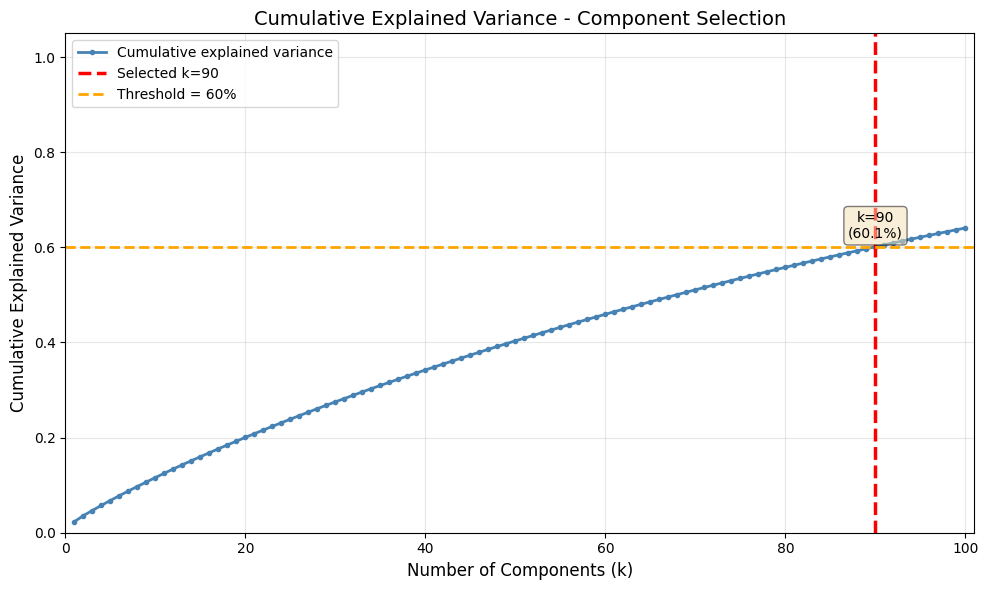


✓ Cumulative variance plot: k=90 selected at 60% threshold
  To adjust: change 'variance_threshold' variable (currently 0.6)


In [67]:
# Visualize cumulative explained variance and threshold
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot cumulative explained variance
ax.plot(range(1, min(101, n_components+1)), cumulative_variance[:min(100, n_components)], 
        'o-', markersize=3, linewidth=2, label='Cumulative explained variance', color='steelblue')

# Mark selected k
ax.axvline(x=elbow_k, color='r', linestyle='--', linewidth=2.5, label=f'Selected k={elbow_k}')
ax.axhline(y=variance_threshold, color='orange', linestyle='--', linewidth=2, 
           label=f'Threshold = {variance_threshold*100:.0f}%')

# Add text annotation at intersection
ax.text(elbow_k, variance_threshold + 0.02, f'k={elbow_k}\n({cumulative_variance[elbow_k-1]*100:.1f}%)', 
        fontsize=10, ha='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Number of Components (k)', fontsize=12)
ax.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax.set_title('Cumulative Explained Variance - Component Selection', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, min(101, n_components+1))
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print(f"\n✓ Cumulative variance plot: k={elbow_k} selected at {variance_threshold*100:.0f}% threshold")
print(f"  To adjust: change 'variance_threshold' variable (currently {variance_threshold})")


In [68]:
# Extract principal components (loadings) matrix with k_source components
# Shape: (k_source, num_columns) - dominant axes in neuron space
# NOTE: Uses firing_rate_normalized_source (subset matrix from selected source brain regions)
k_source = int(elbow_k)  # Rename for clarity - ensure int
n_neurons_source = firing_rate_normalized_source.shape[0]  # Number of neurons (n_samples)
n_features_source = firing_rate_normalized_source.shape[1]  # Number of time bins (n_features)
max_k_source = min(n_neurons_source, n_features_source)  # PCA constraint

# Cap k_source at max allowed by PCA
if k_source > max_k_source:
    print(f"Warning: k_source={k_source} exceeds max allowed ({max_k_source}). Capping to {max_k_source}.")
    k_source = max_k_source

print(f"Extracting principal components matrix with k_source={k_source} components...")
print(f"  Matrix shape: {firing_rate_normalized_source.shape} (n_neurons={n_neurons_source}, n_features={n_features_source})")
print(f"  Max k allowed: {max_k_source}")

# Refit PCA with k_source components
# NOTE: Fitting on firing_rate_normalized_source (subset matrix, not full matrix)
pca_source = PCA(n_components=k_source)
pca_source.fit(firing_rate_normalized_source)

# Extract principal components (loadings)
# These are the axes in neuron space: shape (k_source, n_features)
principal_components_source = pca_source.components_  # Shape: (k_source, num_columns)

# Compute scores: (n_units, k_source)
# NOTE: Transforming firing_rate_normalized_source (subset matrix, not full matrix)
scores_source = pca_source.transform(firing_rate_normalized_source)  # Shape: (n_units, k_source)

print(f"\n=== Source Principal Components Matrix ===")
print(f"Principal components shape: {principal_components_source.shape} (k_source × num_columns)")
print(f"  k_source (components): {principal_components_source.shape[0]}")
print(f"  num_columns (features): {principal_components_source.shape[1]}")
print(f"\nScores shape: {scores_source.shape} (n_units × k_source)")
print(f"  n_units: {scores_source.shape[0]}")
print(f"  k_source: {scores_source.shape[1]}")

print(f"\nExplained variance:")
print(f"  Total (k_source components): {pca_source.explained_variance_ratio_.sum():.4f} ({pca_source.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"  Per component:")
for i in range(k_source):
    print(f"    PC{i+1}: {pca_source.explained_variance_ratio_[i]:.4f} ({pca_source.explained_variance_ratio_[i]*100:.2f}%)")

print(f"\n✓ Source principal components matrix extracted: shape ({k_source}, {firing_rate_normalized_source.shape[1]})")


Extracting principal components matrix with k_source=90 components...
  Matrix shape: (360, 522) (n_neurons=360, n_features=522)
  Max k allowed: 360

=== Source Principal Components Matrix ===
Principal components shape: (90, 522) (k_source × num_columns)
  k_source (components): 90
  num_columns (features): 522

Scores shape: (360, 90) (n_units × k_source)
  n_units: 360
  k_source: 90

Explained variance:
  Total (k_source components): 0.5957 (59.57%)
  Per component:
    PC1: 0.0231 (2.31%)
    PC2: 0.0127 (1.27%)
    PC3: 0.0109 (1.09%)
    PC4: 0.0106 (1.06%)
    PC5: 0.0104 (1.04%)
    PC6: 0.0101 (1.01%)
    PC7: 0.0098 (0.98%)
    PC8: 0.0096 (0.96%)
    PC9: 0.0094 (0.94%)
    PC10: 0.0093 (0.93%)
    PC11: 0.0092 (0.92%)
    PC12: 0.0090 (0.90%)
    PC13: 0.0087 (0.87%)
    PC14: 0.0085 (0.85%)
    PC15: 0.0084 (0.84%)
    PC16: 0.0083 (0.83%)
    PC17: 0.0083 (0.83%)
    PC18: 0.0081 (0.81%)
    PC19: 0.0080 (0.80%)
    PC20: 0.0079 (0.79%)
    PC21: 0.0078 (0.78%)
    PC22

In [69]:
# Store source PCA results
print("=== Stored Source PCA Results ===")
print(f"k_source: {k_source}")
print(f"Principal components matrix: shape {principal_components_source.shape}")
print(f"Scores matrix: shape {scores_source.shape}")
print(f"Explained variance ratio (k_source components): {pca_source.explained_variance_ratio_}")
print(f"Cumulative variance (k_source components): {cumulative_variance[k_source-1]:.4f}")

# Store for later use
pca_model_source = pca_source
k_components_source = k_source
pc_matrix_source = principal_components_source  # Shape: (k_source, num_columns) - axes in neuron space
score_matrix_source = scores_source  # Shape: (n_units, k_source)

print(f"\n✓ Source PCA results stored: k_source={k_source}")
print(f"  Ready for target PCA (Section 7) with k_target = k_source / 2")


=== Stored Source PCA Results ===
k_source: 90
Principal components matrix: shape (90, 522)
Scores matrix: shape (360, 90)
Explained variance ratio (k_source components): [0.02309373 0.01265685 0.01094701 0.01063153 0.01038718 0.01007032
 0.00980901 0.00957681 0.00940175 0.00928601 0.00917091 0.00899652
 0.0087464  0.00854124 0.00841271 0.00833424 0.00825586 0.00806357
 0.00804244 0.00788635 0.00780851 0.00773329 0.00767217 0.00759274
 0.00749548 0.00744819 0.00738365 0.0072877  0.00715662 0.00705541
 0.00703125 0.00698363 0.00694442 0.00679724 0.00666038 0.00664449
 0.0065947  0.00648387 0.00645079 0.00639728 0.00630181 0.00627807
 0.00621167 0.00616728 0.00615827 0.00608325 0.00605328 0.00591285
 0.00587858 0.00581174 0.00575214 0.00573314 0.00568678 0.00562721
 0.00561879 0.00553864 0.00548837 0.00540421 0.00535476 0.00532823
 0.00528031 0.00521803 0.00513532 0.00510639 0.00506207 0.00501287
 0.00498786 0.00492262 0.004903   0.00486527 0.00482807 0.00477429
 0.00468315 0.00464661 0.

## 7. PCA Analysis (Target)

Run PCA on the target subset matrix (`firing_rate_normalized_target`) using k_target = k_source / 2.
This uses half the number of components from the source PCA.

**Naming Convention:**
- `firing_rate_normalized_target`: Subset matrix containing only units from selected target brain regions (e.g., pre_supplementary_motor_area)
- `firing_rate_normalized`: Full matrix with all units (NOT used in this section)
- `k_target`: Number of principal components for target PCA (typically k_source / 2)


In [70]:
# Determine k for target matrix: 1/2 of source matrix k
# NOTE: Uses firing_rate_normalized_target (subset matrix from selected target brain regions)
k_source = int(k_components_source)  # k from source PCA (Section 6) - ensure int
k_target = int(max(1, k_source // 2))  # Target k is 1/2 of source k (minimum 1) - ensure int

# Check PCA constraint: n_components <= min(n_samples, n_features)
# NOTE: Using firing_rate_normalized_target (subset matrix, not full matrix)
n_neurons_target = firing_rate_normalized_target.shape[0]  # Number of neurons (n_samples)
n_features_target = firing_rate_normalized_target.shape[1]  # Number of time bins (n_features)
max_k_target = min(n_neurons_target, n_features_target)  # PCA constraint

# Cap k_target at max allowed by PCA
if k_target > max_k_target:
    print(f"Warning: k_target={k_target} exceeds max allowed ({max_k_target}). Capping to {max_k_target}.")
    k_target = max_k_target

print("=== Target Matrix PCA Setup ===")
print(f"Source matrix k (from Section 6): {k_source}")
print(f"Target matrix k: {k_target} (1/2 of source k, capped at max)")
print(f"Target matrix shape: {firing_rate_normalized_target.shape} (units × time bins)")
print(f"  n_neurons: {n_neurons_target}, n_features: {n_features_target}")
print(f"  Max k allowed: {max_k_target}")


=== Target Matrix PCA Setup ===
Source matrix k (from Section 6): 90
Target matrix k: 45 (1/2 of source k, capped at max)
Target matrix shape: (206, 522) (units × time bins)
  n_neurons: 206, n_features: 522
  Max k allowed: 206


In [71]:
# Run PCA on target matrix with k_target components
# NOTE: Uses firing_rate_normalized_target (subset matrix from selected target brain regions)
#       NOT firing_rate_normalized (full matrix with all units)
print(f"\nRunning PCA on target matrix with k_target={k_target} components...")

# Fit PCA with k_target components
# NOTE: Fitting on firing_rate_normalized_target (subset matrix, not full matrix)
pca_target = PCA(n_components=k_target)
pca_target.fit(firing_rate_normalized_target)

# Extract principal components (loadings)
# These are the axes in neuron space: shape (k_target, n_features)
principal_components_target = pca_target.components_  # Shape: (k_target, num_columns)

# Compute scores: (n_units, k_target)
# NOTE: Transforming firing_rate_normalized_target (subset matrix, not full matrix)
scores_target = pca_target.transform(firing_rate_normalized_target)  # Shape: (n_units, k_target)

print(f"\n=== Target Matrix PCA Results ===")
print(f"Principal components shape: {principal_components_target.shape} (k_target × num_columns)")
print(f"  k_target (components): {principal_components_target.shape[0]}")
print(f"  num_columns (features): {principal_components_target.shape[1]}")
print(f"\nScores shape: {scores_target.shape} (n_units × k_target)")
print(f"  n_units: {scores_target.shape[0]}")
print(f"  k_target: {scores_target.shape[1]}")

print(f"\nExplained variance:")
print(f"  Total (k_target components): {pca_target.explained_variance_ratio_.sum():.4f} ({pca_target.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"  Per component:")
for i in range(k_target):
    print(f"    PC{i+1}: {pca_target.explained_variance_ratio_[i]:.4f} ({pca_target.explained_variance_ratio_[i]*100:.2f}%)")

print(f"\n✓ Target matrix PCA completed: shape ({k_target}, {firing_rate_normalized_target.shape[1]})")



Running PCA on target matrix with k_target=45 components...

=== Target Matrix PCA Results ===
Principal components shape: (45, 522) (k_target × num_columns)
  k_target (components): 45
  num_columns (features): 522

Scores shape: (206, 45) (n_units × k_target)
  n_units: 206
  k_target: 45

Explained variance:
  Total (k_target components): 0.4673 (46.73%)
  Per component:
    PC1: 0.0241 (2.41%)
    PC2: 0.0147 (1.47%)
    PC3: 0.0139 (1.39%)
    PC4: 0.0138 (1.38%)
    PC5: 0.0132 (1.32%)
    PC6: 0.0129 (1.29%)
    PC7: 0.0125 (1.25%)
    PC8: 0.0125 (1.25%)
    PC9: 0.0121 (1.21%)
    PC10: 0.0120 (1.20%)
    PC11: 0.0118 (1.18%)
    PC12: 0.0116 (1.16%)
    PC13: 0.0114 (1.14%)
    PC14: 0.0113 (1.13%)
    PC15: 0.0110 (1.10%)
    PC16: 0.0108 (1.08%)
    PC17: 0.0107 (1.07%)
    PC18: 0.0106 (1.06%)
    PC19: 0.0105 (1.05%)
    PC20: 0.0102 (1.02%)
    PC21: 0.0101 (1.01%)
    PC22: 0.0100 (1.00%)
    PC23: 0.0098 (0.98%)
    PC24: 0.0096 (0.96%)
    PC25: 0.0095 (0.95%)
    PC

In [72]:
# Store target PCA results
print("=== Stored Target PCA Results ===")
print(f"k_target: {k_target}")
print(f"Principal components matrix: shape {principal_components_target.shape}")
print(f"Scores matrix: shape {scores_target.shape}")
print(f"Explained variance ratio: {pca_target.explained_variance_ratio_}")

# Store for later use
pca_model_target = pca_target
k_components_target = k_target
pc_matrix_target = principal_components_target  # Shape: (k_target, num_columns) - axes in neuron space
score_matrix_target = scores_target  # Shape: (n_units, k_target)

print(f"\n✓ Target PCA results stored")
print(f"  Comparison: Source k={k_source}, Target k={k_target} (target = source / 2)")


=== Stored Target PCA Results ===
k_target: 45
Principal components matrix: shape (45, 522)
Scores matrix: shape (206, 45)
Explained variance ratio: [0.02412729 0.01474047 0.01394683 0.01379449 0.01316178 0.01286887
 0.01254775 0.01247321 0.01213125 0.01202419 0.01176352 0.01158447
 0.01143371 0.01127975 0.01104738 0.01082933 0.01069302 0.01061896
 0.01052036 0.01023393 0.01006675 0.00998851 0.00983679 0.00958956
 0.00948463 0.00935692 0.00930641 0.00921812 0.00910876 0.00896123
 0.00884537 0.00866053 0.00861025 0.00846939 0.00837594 0.00824461
 0.00816517 0.00805122 0.00795987 0.00776505 0.00762611 0.0075914
 0.00749712 0.00746005 0.00719148]

✓ Target PCA results stored
  Comparison: Source k=90, Target k=45 (target = source / 2)


## 8. Ridge Regression for Null Space Estimation

Estimate the mapping matrix W from regression epoch to projection epoch PCA components using ridge regression, trained only on regression epoch columns.


In [73]:
# Step 1: Verify Regression/Projection Index Vectors
# Use existing idx_regression (regression epoch) and idx_project (projection epoch) from Section 4

print("=== Regression/Projection Index Vectors ===")
print(f"Total columns in combined matrix: {firing_rate_combined.shape[1]}")
print(f"  Regression epoch (idx_regression): {idx_regression.sum()} columns")
print(f"  Projection epoch (idx_project): {idx_project.sum()} columns")
print(f"\nVerification:")
print(f"  idx_project + idx_regression should equal all True: {(idx_project | idx_regression).all()}")
print(f"  No overlap: {(idx_project & idx_regression).sum() == 0}")
print(f"\n✓ Index vectors ready:")
print(f"  idx_regression: regression epoch columns")
print(f"  idx_project: projection epoch columns")


=== Regression/Projection Index Vectors ===
Total columns in combined matrix: 522
  Regression epoch (idx_regression): 122 columns
  Projection epoch (idx_project): 400 columns

Verification:
  idx_project + idx_regression should equal all True: True
  No overlap: True

✓ Index vectors ready:
  idx_regression: regression epoch columns
  idx_project: projection epoch columns


In [74]:
# Step 2: Extract Training Matrices
# Training uses only regression epoch columns

# Extract SOURCE PCA components (activity from area that sends output)
# N_train should have k_source rows
N_train = pc_matrix_source[:, idx_regression]   # shape: (k_source, num_regression_cols)

# Extract TARGET PCA components (activity or behavior that receives)
# M_train should have k_target rows
M_train = pc_matrix_target[:, idx_regression]   # shape: (k_target, num_regression_cols)

print("=== Training Matrices ===")
print(f"N_train (SOURCE PCA, regression epoch columns): shape {N_train.shape}")
print(f"  k_source: {N_train.shape[0]} (should be {k_components_source})")
print(f"  num_regression_cols: {N_train.shape[1]}")
print(f"\nM_train (TARGET PCA, regression epoch columns): shape {M_train.shape}")
print(f"  k_target: {M_train.shape[0]} (should be {k_components_target})")
print(f"  num_regression_cols: {M_train.shape[1]}")

print(f"\n✓ Training matrices extracted (using regression epoch columns only)")


=== Training Matrices ===
N_train (SOURCE PCA, regression epoch columns): shape (90, 122)
  k_source: 90 (should be 90)
  num_regression_cols: 122

M_train (TARGET PCA, regression epoch columns): shape (45, 122)
  k_target: 45 (should be 45)
  num_regression_cols: 122

✓ Training matrices extracted (using regression epoch columns only)


In [75]:
# Step 3: Implement Ridge Regression
# Ridge regression: M ≈ W * N
# W = (M_train @ N_train.T) @ inv(N_train @ N_train.T + lam * I_k_source)
# Shape: (k_target, k_source)

# Set ridge regularization parameter
lam = 0.1  # Can be adjusted/tuned

print("=== Ridge Regression Setup ===")
print(f"Ridge parameter λ: {lam}")
print(f"N_train shape: {N_train.shape} (k_source × num_fit_cols)")
print(f"M_train shape: {M_train.shape} (k_target × num_fit_cols)")

# Compute components of ridge regression formula
# N_train @ N_train.T: shape (k_source, k_source)
NNT = N_train @ N_train.T

# Identity matrix scaled by lambda: λ * I_k_source
I_k = lam * np.eye(N_train.shape[0])  # N_train.shape[0] = k_source

# Regularized covariance: N_train @ N_train.T + λ * I_k_source
regularized_cov = NNT + I_k

# Compute inverse: inv(N_train @ N_train.T + λ * I_k_source)
regularized_cov_inv = np.linalg.inv(regularized_cov)

# M_train @ N_train.T: shape (k_target, k_source)
MNT = M_train @ N_train.T

# Final W: shape (k_target, k_source)
W = (MNT @ regularized_cov_inv)

print(f"\n=== Ridge Regression Results ===")
print(f"W shape: {W.shape} (k_target × k_source)")
print(f"  k_target: {W.shape[0]}")
print(f"  k_source: {W.shape[1]}")
print(f"\nW statistics:")
print(f"  Mean: {W.mean():.6f}")
print(f"  Std: {W.std():.6f}")
print(f"  Min: {W.min():.6f}")
print(f"  Max: {W.max():.6f}")
print(f"\n✓ Ridge regression completed")


=== Ridge Regression Setup ===
Ridge parameter λ: 0.1
N_train shape: (90, 122) (k_source × num_fit_cols)
M_train shape: (45, 122) (k_target × num_fit_cols)

=== Ridge Regression Results ===
W shape: (45, 90) (k_target × k_source)
  k_target: 45
  k_source: 90

W statistics:
  Mean: -0.001755
  Std: 0.057815
  Min: -0.224389
  Max: 0.736616

✓ Ridge regression completed


In [76]:
# Step 4: Store and Verify Results

# Store W matrix and ridge parameter
W_matrix = W
lambda_ridge_value = lam

print("=== Stored Ridge Regression Results ===")
print(f"W_matrix shape: {W_matrix.shape} (k_target × k_source)")
print(f"  k_target: {W_matrix.shape[0]}")
print(f"  k_source: {W_matrix.shape[1]}")
print(f"\nLambda (ridge parameter): {lambda_ridge_value}")
print(f"\nW_matrix statistics:")
print(f"  Mean: {W_matrix.mean():.6f}")
print(f"  Std: {W_matrix.std():.6f}")
print(f"  Min: {W_matrix.min():.6f}")
print(f"  Max: {W_matrix.max():.6f}")

# Verify dimensions
assert W_matrix.shape == (k_components_target, k_components_source), \
    f"W_matrix shape mismatch: expected ({k_components_target}, {k_components_source}), got {W_matrix.shape}"

print(f"\n✓ W matrix stored and verified")
print(f"  Ready for null space projection")


=== Stored Ridge Regression Results ===
W_matrix shape: (45, 90) (k_target × k_source)
  k_target: 45
  k_source: 90

Lambda (ridge parameter): 0.1

W_matrix statistics:
  Mean: -0.001755
  Std: 0.057815
  Min: -0.224389
  Max: 0.736616

✓ W matrix stored and verified
  Ready for null space projection


## 9. SVD Decomposition for Potent/Null Spaces

Decompose W using SVD to identify potent and null spaces in source space. The potent basis spans the dimensions that map from target to source, while the null space is the orthogonal complement in R^k_source.


In [77]:
# Step 1: Perform SVD on W
# W = U @ diag(S) @ Vt

print("=== SVD Decomposition of W ===")
print(f"W shape: {W.shape} (k_target × k_source)")

# Perform SVD
U, S, Vt = np.linalg.svd(W, full_matrices=False)

print(f"\nSVD Results:")
print(f"  U shape: {U.shape} (k_target × rank)")
print(f"  S length: {len(S)}")
print(f"  Vt shape: {Vt.shape} (rank × k_source)")

# Identify non-zero singular values (with tolerance for numerical precision)
tolerance = 1e-8
rank = (S > tolerance).sum()

print(f"\nSingular values:")
print(f"  Total: {len(S)}")
print(f"  Non-zero (rank): {rank} (tolerance: {tolerance})")
print(f"  Range: [{S.min():.6e}, {S.max():.6e}]")
print(f"\nNon-zero singular values:")
for i in range(min(rank, 10)):
    print(f"  σ{i+1}: {S[i]:.6e}")
if rank > 10:
    print(f"  ... ({rank - 10} more)")

print(f"\n✓ SVD decomposition completed")
print(f"  Rank: {rank} (≤ k_source = {N_train.shape[0]})")


=== SVD Decomposition of W ===
W shape: (45, 90) (k_target × k_source)

SVD Results:
  U shape: (45, 45) (k_target × rank)
  S length: 45
  Vt shape: (45, 90) (rank × k_source)

Singular values:
  Total: 45
  Non-zero (rank): 45 (tolerance: 1e-08)
  Range: [1.655985e-01, 9.315058e-01]

Non-zero singular values:
  σ1: 9.315058e-01
  σ2: 8.893734e-01
  σ3: 8.642430e-01
  σ4: 8.324536e-01
  σ5: 8.059411e-01
  σ6: 7.782498e-01
  σ7: 7.582190e-01
  σ8: 7.475841e-01
  σ9: 7.091054e-01
  σ10: 7.000272e-01
  ... (35 more)

✓ SVD decomposition completed
  Rank: 45 (≤ k_source = 90)


In [78]:
# Step 2: Extract Potent Basis and Compute Projection Matrices
# Potent basis in source space = rows of V^T for non-zero singular values

# Extract potent basis: V_pot = Vt[:rank, :] in source space
V_pot = Vt[:rank, :]  # Shape: (rank, k_source) in source space

# Compute null dimension
null_dim = N_train.shape[0] - rank  # N_train.shape[0] = k_source

print("=== Potent Basis ===")
print(f"V_pot shape: {V_pot.shape} (rank × k_source)")
print(f"  rank: {rank}")
print(f"  k_source: {V_pot.shape[1]}")
print(f"\nNull dimension:")
print(f"  null_dim = N_train.shape[0] - rank = {N_train.shape[0]} - {rank} = {null_dim}")
print(f"  Expected: null_dim ≥ 0")

# Compute projection matrices
# P_pot: projection onto potent space (k_source × k_source)
P_pot = V_pot.T @ V_pot  # Shape: (k_source, k_source)

# P_null: projection onto null space (k_source × k_source)
P_null = np.eye(N_train.shape[0]) - P_pot  # Shape: (k_source, k_source)

print(f"\n=== Projection Matrices ===")
print(f"P_pot shape: {P_pot.shape} (k_source × k_source)")
print(f"P_null shape: {P_null.shape} (k_source × k_source)")

print(f"\n✓ Potent basis and projection matrices computed")
print(f"  Rank: {rank} (≤ k_source = {N_train.shape[0]})")
print(f"  Null dimension: {null_dim}")


=== Potent Basis ===
V_pot shape: (45, 90) (rank × k_source)
  rank: 45
  k_source: 90

Null dimension:
  null_dim = N_train.shape[0] - rank = 90 - 45 = 45
  Expected: null_dim ≥ 0

=== Projection Matrices ===
P_pot shape: (90, 90) (k_source × k_source)
P_null shape: (90, 90) (k_source × k_source)

✓ Potent basis and projection matrices computed
  Rank: 45 (≤ k_source = 90)
  Null dimension: 45


In [79]:
# Step 3: Verify Projection Matrices

print("=== Verification ===")

# Verify P_pot properties
print(f"P_pot properties:")
print(f"  Shape: {P_pot.shape}")
print(f"  Trace (should equal rank): {np.trace(P_pot):.6f} (rank = {rank})")
print(f"  Symmetric check: {np.allclose(P_pot, P_pot.T)}")

# Verify P_null properties
print(f"\nP_null properties:")
print(f"  Shape: {P_null.shape}")
print(f"  Trace (should equal null_dim): {np.trace(P_null):.6f} (null_dim = {null_dim})")
print(f"  Symmetric check: {np.allclose(P_null, P_null.T)}")

# Verify orthogonality: P_pot @ P_null should be approximately zero
orthogonality_check = P_pot @ P_null
max_orthogonality_error = np.abs(orthogonality_check).max()
print(f"\nOrthogonality check (P_pot @ P_null):")
print(f"  Max absolute value: {max_orthogonality_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if max_orthogonality_error < 1e-10 else '✗'}")

# Verify completeness: P_pot + P_null should equal identity
completeness_check = P_pot + P_null
identity_error = np.abs(completeness_check - np.eye(N_train.shape[0])).max()
print(f"\nCompleteness check (P_pot + P_null = I):")
print(f"  Max absolute error: {identity_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if identity_error < 1e-10 else '✗'}")

print(f"\n✓ Projection matrices verified")


=== Verification ===
P_pot properties:
  Shape: (90, 90)
  Trace (should equal rank): 45.000000 (rank = 45)
  Symmetric check: True

P_null properties:
  Shape: (90, 90)
  Trace (should equal null_dim): 45.000000 (null_dim = 45)
  Symmetric check: True

Orthogonality check (P_pot @ P_null):
  Max absolute value: 6.049340e-16
  Should be ≈ 0: ✓

Completeness check (P_pot + P_null = I):
  Max absolute error: 0.000000e+00
  Should be ≈ 0: ✓

✓ Projection matrices verified


In [80]:
# Step 4: Store Results

# Store SVD components and projection matrices
U_svd = U
S_svd = S
Vt_svd = Vt
V_pot_stored = V_pot
P_pot_stored = P_pot
P_null_stored = P_null
rank_potent = rank
dim_null_stored = null_dim

print("=== Stored SVD Results ===")
print(f"U_svd shape: {U_svd.shape} (k_target × rank)")
print(f"S_svd length: {len(S_svd)}")
print(f"Vt_svd shape: {Vt_svd.shape} (rank × k_source)")
print(f"\nV_pot shape: {V_pot_stored.shape} (rank × k_source)")
print(f"P_pot shape: {P_pot_stored.shape} (k_source × k_source)")
print(f"P_null shape: {P_null_stored.shape} (k_source × k_source)")
print(f"\nrank_potent: {rank_potent}")
print(f"dim_null: {dim_null_stored}")

# Verify dimensions
dim_check = rank_potent + dim_null_stored == N_train.shape[0]
print(f"\nDimension check:")
print(f"  rank_potent + dim_null = {rank_potent} + {dim_null_stored} = {rank_potent + dim_null_stored}")
print(f"  k_source = {N_train.shape[0]}")
print(f"  Match: {'✓' if dim_check else '✗'}")

# Verify reconstruction: W ≈ U @ diag(S) @ Vt
W_reconstructed = U @ np.diag(S) @ Vt
reconstruction_error = np.abs(W - W_reconstructed).max()
print(f"\nReconstruction check (W ≈ U @ diag(S) @ Vt):")
print(f"  Max absolute error: {reconstruction_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if reconstruction_error < 1e-10 else '✗'}")

print(f"\n✓ SVD decomposition completed and verified")
print(f"  Potent space: rank {rank_potent} (in R^k_source = R^{N_train.shape[0]})")
print(f"  Null space: dimension {dim_null_stored} (in R^k_source = R^{N_train.shape[0]})")


=== Stored SVD Results ===
U_svd shape: (45, 45) (k_target × rank)
S_svd length: 45
Vt_svd shape: (45, 90) (rank × k_source)

V_pot shape: (45, 90) (rank × k_source)
P_pot shape: (90, 90) (k_source × k_source)
P_null shape: (90, 90) (k_source × k_source)

rank_potent: 45
dim_null: 45

Dimension check:
  rank_potent + dim_null = 45 + 45 = 90
  k_source = 90
  Match: ✓

Reconstruction check (W ≈ U @ diag(S) @ Vt):
  Max absolute error: 7.771561e-16
  Should be ≈ 0: ✓

✓ SVD decomposition completed and verified
  Potent space: rank 45 (in R^k_source = R^90)
  Null space: dimension 45 (in R^k_source = R^90)


## 10. Projection to All Columns

Project source PCA components for ALL columns (encoding/delay/probe/press) onto the potent and null spaces using P_pot and P_null. This decomposes the entire source activity into components that map to target (potent) and components that do not (null).


In [81]:
# Step 1: Extract Source PCA Components for All Columns
# N_all: (k_source, T_all) source PCs for any columns (encoding/delay/probe/press)

# Extract source PCA components for all columns
N_all = pc_matrix_source  # Shape: (k_source, T_all) where T_all = total number of time bins
T_all = N_all.shape[1]

print("=== Source PCA Components for All Columns ===")
print(f"N_all shape: {N_all.shape} (k_source × T_all)")
print(f"  k_source: {N_all.shape[0]}")
print(f"  T_all (total columns): {T_all}")
print(f"\nEpoch breakdown:")
print(f"  Projection epoch (idx_project): {idx_project.sum()} columns")
print(f"  Regression epoch (idx_regression): {idx_regression.sum()} columns")
print(f"  Total: {idx_project.sum() + idx_regression.sum()} columns")

print(f"\n✓ N_all extracted: source PCA components for all time bins")


=== Source PCA Components for All Columns ===
N_all shape: (90, 522) (k_source × T_all)
  k_source: 90
  T_all (total columns): 522

Epoch breakdown:
  Projection epoch (idx_project): 400 columns
  Regression epoch (idx_regression): 122 columns
  Total: 522 columns

✓ N_all extracted: source PCA components for all time bins


In [82]:
# Step 2: Project onto Potent Space
# N_pot = P_pot @ N_all

print("=== Projection onto Potent Space ===")
print(f"P_pot shape: {P_pot.shape} (k_source × k_source)")
print(f"N_all shape: {N_all.shape} (k_source × T_all)")

# Project N_all onto potent space
N_pot = P_pot @ N_all  # Shape: (k_source, T_all)

print(f"\nN_pot shape: {N_pot.shape} (k_source × T_all)")
print(f"  k_source: {N_pot.shape[0]}")
print(f"  T_all: {N_pot.shape[1]}")

print(f"\nN_pot statistics:")
print(f"  Mean: {N_pot.mean():.6f}")
print(f"  Std: {N_pot.std():.6f}")
print(f"  Min: {N_pot.min():.6f}")
print(f"  Max: {N_pot.max():.6f}")

print(f"\n✓ Potent projection completed")
print(f"  N_pot represents component that maps to target (regression epoch)")


=== Projection onto Potent Space ===
P_pot shape: (90, 90) (k_source × k_source)
N_all shape: (90, 522) (k_source × T_all)

N_pot shape: (90, 522) (k_source × T_all)
  k_source: 90
  T_all: 522

N_pot statistics:
  Mean: 0.000000
  Std: 0.030949
  Min: -0.123633
  Max: 0.128522

✓ Potent projection completed
  N_pot represents component that maps to target (regression epoch)


In [83]:
# Step 3: Project onto Null Space
# N_null = P_null @ N_all

print("=== Projection onto Null Space ===")
print(f"P_null shape: {P_null.shape} (k_source × k_source)")
print(f"N_all shape: {N_all.shape} (k_source × T_all)")

# Project N_all onto null space
N_null = P_null @ N_all  # Shape: (k_source, T_all)

print(f"\nN_null shape: {N_null.shape} (k_source × T_all)")
print(f"  k_source: {N_null.shape[0]}")
print(f"  T_all: {N_null.shape[1]}")

print(f"\nN_null statistics:")
print(f"  Mean: {N_null.mean():.6f}")
print(f"  Std: {N_null.std():.6f}")
print(f"  Min: {N_null.min():.6f}")
print(f"  Max: {N_null.max():.6f}")

print(f"\n✓ Null projection completed")
print(f"  N_null represents component that does NOT map to target")


=== Projection onto Null Space ===
P_null shape: (90, 90) (k_source × k_source)
N_all shape: (90, 522) (k_source × T_all)

N_null shape: (90, 522) (k_source × T_all)
  k_source: 90
  T_all: 522

N_null statistics:
  Mean: 0.000000
  Std: 0.030949
  Min: -0.136323
  Max: 0.147301

✓ Null projection completed
  N_null represents component that does NOT map to target


In [84]:
# Step 4: Verify Decomposition

print("=== Verification ===")

# Verify that potent + null = original
N_all_reconstructed = N_pot + N_null
reconstruction_error = np.abs(N_all - N_all_reconstructed).max()
print(f"Reconstruction check (N_pot + N_null = N_all):")
print(f"  Max absolute error: {reconstruction_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if reconstruction_error < 1e-10 else '✗'}")

# Verify orthogonality: N_pot.T @ N_null should be approximately zero
orthogonality_matrix = N_pot.T @ N_null  # Shape: (T_all, T_all)
max_orthogonality_error = np.abs(orthogonality_matrix).max()
print(f"\nOrthogonality check (N_pot.T @ N_null ≈ 0):")
print(f"  Max absolute value: {max_orthogonality_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if max_orthogonality_error < 1e-10 else '✗'}")

# Compute variance explained by each component
variance_all = np.var(N_all, axis=0).sum()  # Total variance
variance_pot = np.var(N_pot, axis=0).sum()  # Variance in potent space
variance_null = np.var(N_null, axis=0).sum()  # Variance in null space
variance_ratio = variance_pot / variance_null if variance_null > 0 else np.inf

print(f"\nVariance explained:")
print(f"  Total variance (N_all): {variance_all:.6f}")
print(f"  Potent variance (N_pot): {variance_pot:.6f} ({variance_pot/variance_all*100:.2f}%)")
print(f"  Null variance (N_null): {variance_null:.6f} ({variance_null/variance_all*100:.2f}%)")
print(f"  Potent/Null ratio: {variance_ratio:.4f}")

# Verify variance decomposition (should be approximately equal due to orthogonality)
variance_sum = variance_pot + variance_null
variance_decomp_error = np.abs(variance_all - variance_sum) / variance_all
print(f"\nVariance decomposition check:")
print(f"  variance_pot + variance_null = {variance_sum:.6f}")
print(f"  Relative error: {variance_decomp_error:.6e}")
print(f"  Should be ≈ 0: {'✓' if variance_decomp_error < 1e-6 else '✗'}")

print(f"\n✓ Decomposition verified")


=== Verification ===
Reconstruction check (N_pot + N_null = N_all):
  Max absolute error: 1.110223e-16
  Should be ≈ 0: ✓

Orthogonality check (N_pot.T @ N_null ≈ 0):
  Max absolute value: 1.410445e-16
  Should be ≈ 0: ✓

Variance explained:
  Total variance (N_all): 0.988889
  Potent variance (N_pot): 0.494844 (50.04%)
  Null variance (N_null): 0.494045 (49.96%)
  Potent/Null ratio: 1.0016

Variance decomposition check:
  variance_pot + variance_null = 0.988889
  Relative error: 1.122697e-16
  Should be ≈ 0: ✓

✓ Decomposition verified


In [85]:
# Step 5: Store Results

# Store all projection results
N_all_stored = N_all
N_pot_stored = N_pot
N_null_stored = N_null

# Store variance statistics
projection_stats = {
    'variance_all': variance_all,
    'variance_pot': variance_pot,
    'variance_null': variance_null,
    'variance_ratio': variance_ratio,
    'reconstruction_error': reconstruction_error,
    'orthogonality_error': max_orthogonality_error
}

print("=== Stored Projection Results ===")
print(f"N_all_stored shape: {N_all_stored.shape} (k_source × T_all)")
print(f"N_pot_stored shape: {N_pot_stored.shape} (k_source × T_all)")
print(f"N_null_stored shape: {N_null_stored.shape} (k_source × T_all)")
print(f"\nProjection statistics:")
print(f"  Variance ratio (pot/null): {projection_stats['variance_ratio']:.4f}")
print(f"  Reconstruction error: {projection_stats['reconstruction_error']:.6e}")
print(f"  Orthogonality error: {projection_stats['orthogonality_error']:.6e}")

print(f"\n✓ All projection results stored")
print(f"  Ready for further analysis and visualization")


=== Stored Projection Results ===
N_all_stored shape: (90, 522) (k_source × T_all)
N_pot_stored shape: (90, 522) (k_source × T_all)
N_null_stored shape: (90, 522) (k_source × T_all)

Projection statistics:
  Variance ratio (pot/null): 1.0016
  Reconstruction error: 1.110223e-16
  Orthogonality error: 1.410445e-16

✓ All projection results stored
  Ready for further analysis and visualization


## 11. Per-Epoch Null vs Potent Occupancy (Tuning Ratio)

Compute tuning ratio (TR) for each epoch by measuring dimension-normalized energy in potent vs null spaces. Expected: TR > 1 in projection epoch (more null space activity), TR decreases in regression epoch (more potent space activity). Include bootstrap confidence intervals.


In [86]:
# Step 1: Create Epoch Column Masks
# Currently we have idx_project (projection epoch) and idx_regression (regression epoch)

print("=== Epoch Column Masks ===")
print(f"Total columns: {N_all.shape[1]}")

print(f"\nidx_project (projection epoch):")
print(f"  Number of columns: {idx_project.sum()}")
print(f"  Column indices: {np.where(idx_project)[0][:10]}..." if idx_project.sum() > 10 else f"  Column indices: {np.where(idx_project)[0]}")

print(f"\nidx_regression (regression epoch):")
print(f"  Number of columns: {idx_regression.sum()}")
print(f"  Column indices: {np.where(idx_regression)[0][:10]}..." if idx_regression.sum() > 10 else f"  Column indices: {np.where(idx_regression)[0]}")

# Store epoch masks
epoch_masks = {
    'projection': idx_project,  # Projection epoch
    'regression': idx_regression       # Regression epoch
}

print(f"\n✓ Epoch masks created:")
print(f"  projection: {epoch_masks['projection'].sum()} columns")
print(f"  regression: {epoch_masks['regression'].sum()} columns")


=== Epoch Column Masks ===
Total columns: 522

idx_project (projection epoch):
  Number of columns: 400
  Column indices: [0 1 2 3 4 5 6 7 8 9]...

idx_regression (regression epoch):
  Number of columns: 122
  Column indices: [400 401 402 403 404 405 406 407 408 409]...

✓ Epoch masks created:
  projection: 400 columns
  regression: 122 columns


In [87]:
# Step 2: Compute Energy Functions
# E_pot(E) = (1/r) * <||P_pot @ N_E||_F^2>
# E_null(E) = (1/(k-r)) * <||P_null @ N_E||_F^2>

# Get dimensions
r = rank_potent  # Rank of potent space
k = N_all.shape[0]  # k_source

print("=== Energy Computation Setup ===")
print(f"r (rank_potent): {r}")
print(f"k (k_source): {k}")
print(f"k - r (null_dim): {k - r}")

def compute_energy(epoch_mask):
    """
    Compute dimension-normalized energy in potent and null spaces for an epoch.
    
    Args:
        epoch_mask: Boolean array indicating columns belonging to epoch
        
    Returns:
        E_pot: Dimension-normalized energy in potent space
        E_null: Dimension-normalized energy in null space
    """
    # Extract source PCs for this epoch
    N_E = N_all[:, epoch_mask]  # Shape: (k_source, num_epoch_cols)
    
    if N_E.shape[1] == 0:
        return np.nan, np.nan
    
    # Project onto potent space: P_pot @ N_E
    N_E_pot = P_pot @ N_E  # Shape: (k_source, num_epoch_cols)
    
    # Project onto null space: P_null @ N_E
    N_E_null = P_null @ N_E  # Shape: (k_source, num_epoch_cols)
    
    # Compute squared Frobenius norm for each column, then take mean
    # ||A||_F^2 = sum of squares of all elements
    # For each column: ||N_E_pot[:, i]||^2
    frobenius_norm_sq_pot = np.sum(N_E_pot ** 2, axis=0)  # Shape: (num_epoch_cols,)
    frobenius_norm_sq_null = np.sum(N_E_null ** 2, axis=0)  # Shape: (num_epoch_cols,)
    
    # Mean across columns: <||P_pot @ N_E||_F^2>
    mean_frob_sq_pot = np.mean(frobenius_norm_sq_pot)
    mean_frob_sq_null = np.mean(frobenius_norm_sq_null)
    
    # Dimension-normalized energy
    E_pot = (1.0 / r) * mean_frob_sq_pot if r > 0 else np.nan
    E_null = (1.0 / (k - r)) * mean_frob_sq_null if (k - r) > 0 else np.nan
    
    return E_pot, E_null

print(f"\n✓ Energy computation function defined")
print(f"  E_pot(E) = (1/r) * mean(||P_pot @ N_E||_F^2)")
print(f"  E_null(E) = (1/(k-r)) * mean(||P_null @ N_E||_F^2)")


=== Energy Computation Setup ===
r (rank_potent): 45
k (k_source): 90
k - r (null_dim): 45

✓ Energy computation function defined
  E_pot(E) = (1/r) * mean(||P_pot @ N_E||_F^2)
  E_null(E) = (1/(k-r)) * mean(||P_null @ N_E||_F^2)


In [88]:
# Step 3: Compute Tuning Ratio for Each Epoch

print("=== Tuning Ratio Computation ===")

epoch_results = {}

# Compute energy and TR for each epoch
for epoch_name, epoch_mask in epoch_masks.items():
    E_pot_val, E_null_val = compute_energy(epoch_mask)
    
    # Compute tuning ratio: TR = E_null / E_pot
    if E_pot_val > 0 and not np.isnan(E_pot_val) and not np.isnan(E_null_val):
        TR = E_null_val / E_pot_val
    else:
        TR = np.nan
    
    epoch_results[epoch_name] = {
        'E_pot': E_pot_val,
        'E_null': E_null_val,
        'TR': TR,
        'n_columns': epoch_mask.sum()
    }
    
    print(f"\n{epoch_name.upper()} epoch:")
    print(f"  Columns: {epoch_mask.sum()}")
    print(f"  E_pot: {E_pot_val:.6f}")
    print(f"  E_null: {E_null_val:.6f}")
    print(f"  TR = E_null/E_pot: {TR:.4f}")

# Create summary DataFrame
import pandas as pd
results_df = pd.DataFrame(epoch_results).T
results_df.index.name = 'epoch'
results_df = results_df.reset_index()

print(f"\n=== Summary Table ===")
print(results_df.to_string(index=False))

print(f"\n✓ Tuning ratios computed")
print(f"  Expected: TR > 1 in projection epoch (more null space activity)")
print(f"  Expected: TR decreases in regression epoch (more potent space activity)")


=== Tuning Ratio Computation ===

PROJECTION epoch:
  Columns: 400
  E_pot: 0.001919
  E_null: 0.001952
  TR = E_null/E_pot: 1.0174

REGRESSION epoch:
  Columns: 122
  E_pot: 0.001906
  E_null: 0.001796
  TR = E_null/E_pot: 0.9425

=== Summary Table ===
     epoch    E_pot   E_null       TR  n_columns
projection 0.001919 0.001952 1.017433      400.0
regression 0.001906 0.001796 0.942463      122.0

✓ Tuning ratios computed
  Expected: TR > 1 in projection epoch (more null space activity)
  Expected: TR decreases in regression epoch (more potent space activity)


In [89]:
# Step 4: Bootstrap Confidence Intervals

print("=== Bootstrap Confidence Intervals ===")

n_bootstrap = 1000  # Number of bootstrap iterations
bootstrap_results = {}

for epoch_name, epoch_mask in epoch_masks.items():
    # Get column indices for this epoch
    epoch_col_indices = np.where(epoch_mask)[0]
    n_cols = len(epoch_col_indices)
    
    if n_cols == 0:
        bootstrap_results[epoch_name] = {
            'TR_samples': [],
            'TR_mean': np.nan,
            'TR_ci_lower': np.nan,
            'TR_ci_upper': np.nan
        }
        continue
    
    # Bootstrap: resample columns with replacement
    np.random.seed(42)  # For reproducibility
    TR_samples = []
    
    for i in range(n_bootstrap):
        # Resample column indices with replacement
        bootstrap_indices = np.random.choice(epoch_col_indices, size=n_cols, replace=True)
        
        # Create bootstrap mask
        bootstrap_mask = np.zeros(N_all.shape[1], dtype=bool)
        bootstrap_mask[bootstrap_indices] = True
        
        # Compute energy and TR for bootstrap sample
        E_pot_boot, E_null_boot = compute_energy(bootstrap_mask)
        
        if E_pot_boot > 0 and not np.isnan(E_pot_boot) and not np.isnan(E_null_boot):
            TR_boot = E_null_boot / E_pot_boot
            TR_samples.append(TR_boot)
    
    # Compute statistics
    TR_samples = np.array(TR_samples)
    TR_mean = np.mean(TR_samples)
    TR_ci_lower = np.percentile(TR_samples, 2.5)  # 95% CI lower bound
    TR_ci_upper = np.percentile(TR_samples, 97.5)  # 95% CI upper bound
    
    bootstrap_results[epoch_name] = {
        'TR_samples': TR_samples,
        'TR_mean': TR_mean,
        'TR_ci_lower': TR_ci_lower,
        'TR_ci_upper': TR_ci_upper
    }
    
    print(f"\n{epoch_name.upper()} epoch bootstrap:")
    print(f"  Mean TR: {TR_mean:.4f}")
    print(f"  95% CI: [{TR_ci_lower:.4f}, {TR_ci_upper:.4f}]")
    print(f"  Original TR: {epoch_results[epoch_name]['TR']:.4f}")

print(f"\n✓ Bootstrap confidence intervals computed ({n_bootstrap} iterations)")


=== Bootstrap Confidence Intervals ===

PROJECTION epoch bootstrap:
  Mean TR: 1.0179
  95% CI: [0.9949, 1.0424]
  Original TR: 1.0174

REGRESSION epoch bootstrap:
  Mean TR: 0.9434
  95% CI: [0.9049, 0.9790]
  Original TR: 0.9425

✓ Bootstrap confidence intervals computed (1000 iterations)


=== Visualization ===


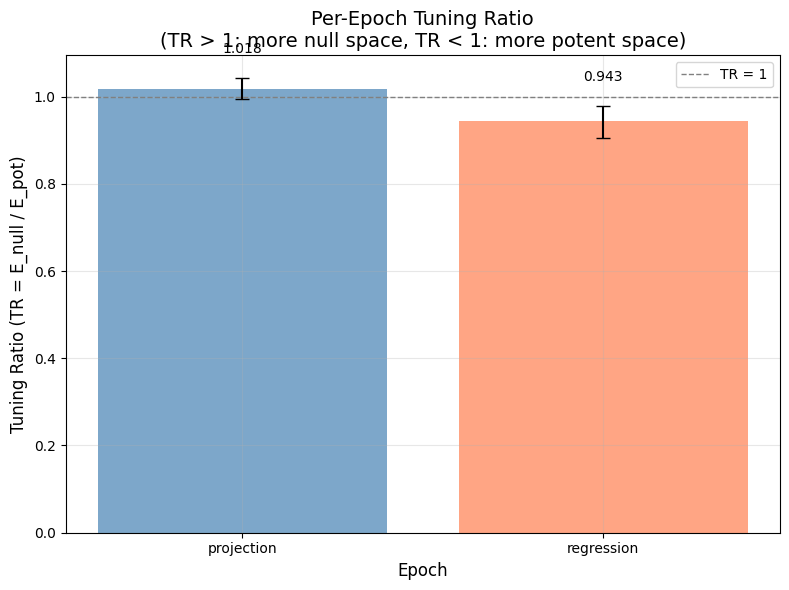


✓ Visualization created
  Expected pattern: TR > 1 in projection epoch, TR decreases in regression epoch


In [90]:
# Step 5: Visualize Results

print("=== Visualization ===")

# Prepare data for plotting
epoch_names = list(epoch_masks.keys())
TR_values = [epoch_results[epoch]['TR'] for epoch in epoch_names]
TR_means = [bootstrap_results[epoch]['TR_mean'] for epoch in epoch_names]
TR_ci_lower = [bootstrap_results[epoch]['TR_ci_lower'] for epoch in epoch_names]
TR_ci_upper = [bootstrap_results[epoch]['TR_ci_upper'] for epoch in epoch_names]

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot bars with error bars
x_pos = np.arange(len(epoch_names))
bars = ax.bar(x_pos, TR_means, yerr=[np.array(TR_means) - np.array(TR_ci_lower), 
                                       np.array(TR_ci_upper) - np.array(TR_means)],
              capsize=5, alpha=0.7, color=['steelblue', 'coral'])

# Add horizontal line at TR=1
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, label='TR = 1')

# Customize plot
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Tuning Ratio (TR = E_null / E_pot)', fontsize=12)
ax.set_title('Per-Epoch Tuning Ratio\n(TR > 1: more null space, TR < 1: more potent space)', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(epoch_names)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for i, (mean, lower, upper) in enumerate(zip(TR_means, TR_ci_lower, TR_ci_upper)):
    ax.text(i, mean + (upper - mean) + 0.05, f'{mean:.3f}', 
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n✓ Visualization created")
print(f"  Expected pattern: TR > 1 in projection epoch, TR decreases in regression epoch")


In [91]:
# Step 6: Store Results

# Store all results
epoch_masks_stored = epoch_masks.copy()
tuning_ratio_results = {
    'epoch_results': epoch_results,
    'bootstrap_results': bootstrap_results,
    'results_df': results_df
}

print("=== Stored Tuning Ratio Results ===")
print(f"Epoch masks stored: {list(epoch_masks_stored.keys())}")
print(f"Epoch results stored: {list(epoch_results.keys())}")
print(f"Bootstrap results stored: {list(bootstrap_results.keys())}")

print(f"\n=== Final Summary Table ===")
summary_df = results_df.copy()
summary_df['TR_mean_boot'] = [bootstrap_results[epoch]['TR_mean'] for epoch in summary_df['epoch']]
summary_df['TR_ci_lower'] = [bootstrap_results[epoch]['TR_ci_lower'] for epoch in summary_df['epoch']]
summary_df['TR_ci_upper'] = [bootstrap_results[epoch]['TR_ci_upper'] for epoch in summary_df['epoch']]
print(summary_df.to_string(index=False))

print(f"\n✓ All tuning ratio results stored")
print(f"  Ready for further analysis and across-subjects comparison")


=== Stored Tuning Ratio Results ===
Epoch masks stored: ['projection', 'regression']
Epoch results stored: ['projection', 'regression']
Bootstrap results stored: ['projection', 'regression']

=== Final Summary Table ===
     epoch    E_pot   E_null       TR  n_columns  TR_mean_boot  TR_ci_lower  TR_ci_upper
projection 0.001919 0.001952 1.017433      400.0      1.017944     0.994915     1.042431
regression 0.001906 0.001796 0.942463      122.0      0.943415     0.904943     0.978955

✓ All tuning ratio results stored
  Ready for further analysis and across-subjects comparison
